# Новости

### Цели работы:

Разработать и реализовать полный конвейер классификации новостных текстов: от предобработки и обучения модели до развертывания API и создания графического интерфейса с возможностью дообучения на новых данных.

### Задачи: 

- Отбор данных 
- Предобработка 
- Тематическое моделирование  
- Векторизация 
- Классификация 
- Парсинг 
- Дообучение 
- API 
- GUI 
- Отчет

#### Установка библиотек и импорт модулей

In [1]:
!pip install pymorphy3

In [2]:
!pip install wordcloud

In [2]:
import pandas as pd
import string
import re
import nltk
import pymorphy3

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer


### Загрузка данных

In [3]:
df1= pd.read_csv("lenta-ru-news.csv",encoding='utf-8',low_memory=False)

In [4]:
df1.head()

,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека,Первая мировая,1914/09/18


#### Описание признаков
- url - полный url-адрес новостной статьи на сайте
- title - заголовок статьи
- text - содержание статьи
- topic - основная тематическая рубрика статьи
- tags - ключевые теги/метки, связанные с новостью
- date - дата публикации статьи 

### Анализ исходных данных

In [5]:
df1.shape

(800975, 6)

In [251]:
#оставляем только необходимые данные
df1 = df1[['title', 'text', 'topic']]

In [252]:
#Проверяем на количество пропусков
print(df1[['title', 'text', 'topic']].isnull().sum())

title    0
text     0
topic    0
dtype: int64


In [253]:
# удаляем строки где столбцы топик и текст пустые
df1 = df1.dropna(subset=['topic'])
df1 = df1.dropna(subset=['text'])

In [9]:
print(df1[['title', 'text', 'topic']].isnull().sum())

title    0
text     0
topic    0
dtype: int64


In [254]:
# Проверяем на количество дубликатов
full_duplicates = df1.duplicated().sum()
full_duplicates

0

In [255]:
# удаляем все дубликаты
df1 = df1.drop_duplicates()

#### Уменьшаем датасет

In [12]:
df_short = df1.sample(n=50000, random_state=42).reset_index(drop=True)

In [13]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Ставим лимит повыше
per_class_limit = 6500 

df_short = df_short.groupby('topic').apply(lambda x: x.sample(min(len(x), per_class_limit), random_state=42)).reset_index(drop=True)

# Проверяем новый объем
print("Новый размер датасета:", len(df_short))
print(df_short['topic'].value_counts())

Новый размер датасета: 42902
topic
Мир                  6500
Россия               6500
Экономика            5364
Спорт                4417
Культура             3715
Наука и техника      3531
Бывший СССР          3526
Интернет и СМИ       2984
Из жизни             1895
Дом                  1483
Силовые структуры    1345
Бизнес                534
Ценности              521
Путешествия           434
69-я параллель         79
Крым                   41
Культпросвет           20
Легпром                 7
Библиотека              6
Name: count, dtype: int64


обрезали количество записей в датасете, чтобы в дальнейшем было удобнее работать

In [14]:
# Оставляем только те темы, где количество новостей хотя бы больше 100
v_counts = df_short['topic'].value_counts()
valid_topics = v_counts[v_counts > 100].index

# Фильтруем датасет
df_short = df_short[df_short['topic'].isin(valid_topics)].reset_index(drop=True)

# Проверяем итог
print("Итоговый чистый размер датасета:", len(df_short))
print(df_short['topic'].value_counts())

Итоговый чистый размер датасета: 42749
topic
Мир                  6500
Россия               6500
Экономика            5364
Спорт                4417
Культура             3715
Наука и техника      3531
Бывший СССР          3526
Интернет и СМИ       2984
Из жизни             1895
Дом                  1483
Силовые структуры    1345
Бизнес                534
Ценности              521
Путешествия           434
Name: count, dtype: int64


In [15]:
df_short.shape

(42749, 3)

In [16]:
df_short['topic'].value_counts()

topic
Мир                  6500
Россия               6500
Экономика            5364
Спорт                4417
Культура             3715
Наука и техника      3531
Бывший СССР          3526
Интернет и СМИ       2984
Из жизни             1895
Дом                  1483
Силовые структуры    1345
Бизнес                534
Ценности              521
Путешествия           434
Name: count, dtype: int64

In [17]:
df_short.head()

,title,text,topic
0,СП «Роснефти» и Statoil начало бурение скважин...,Совместное предприятие «Роснефти» и Statoil AS...,Бизнес
1,Минпромторг завернул проект «Ростеха» по испол...,Министерство промышленности и торговли России ...,Бизнес
2,Россия и Польша договорились о разрешениях на ...,Транспортные власти России и Польши предварите...,Бизнес
3,Nissan отзовет в России почти семь тысяч кросс...,«Ниссан Мэнуфэкчуринг Рус» (официальный предст...,Бизнес
4,Москва и Киев договорились о продлении транзит...,Российская и украинская стороны приняли соглас...,Бизнес


In [18]:
df_short['corpus'] = (df_short['title'].fillna('') + ' ' + 
                df_short['text'].fillna(''))

### Предобработка текста

In [19]:
st = '\xa0—'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [20]:
df_short['prep_text']= [remove_othersymbol(text.lower()) for text in df_short['corpus']]

In [21]:
df_short['prep_text'][0]

'сп «роснефти» и statoil начало бурение скважины в охотском море совместное предприятие «роснефти» и statoil asa начало бурение поисковой скважины в охотском море. об этом говорится в пресс-релизе, опубликованном на сайте нефтяной компании. «”роснефть”   единственная компания в стране, которая продолжает работу по новым проектам на шельфе, несмотря на крайне сложную внешнюю конъюнктуру, в соответствии со своими лицензионными обязательствами»,   отметил в связи с началом работ президент «роснефти» игорь сечин. в сообщении также отмечается, что скважина «ульбериканская-1» будет пробурена на одноименной структуре лицензионного участка «лисянский» на год ранее принятых лицензионных обязательств. расстояние от порта магадан до скважины составляет около 420 километров. вторая скважина проекта «роснефти» и statoil запланирована к бурению в течение сезона 2016 года в периметре участка «магадан-1» в охотском море. полупогружная установка nanhai-9 поставлена китайской компанией china oilfield se

In [22]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [23]:
df_short['prep_text']= [remove_punctuation(text) for text in df_short['prep_text']]

In [24]:
df_short['prep_text'][0]

'сп «роснефти» и statoil начало бурение скважины в охотском море совместное предприятие «роснефти» и statoil asa начало бурение поисковой скважины в охотском море об этом говорится в прессрелизе опубликованном на сайте нефтяной компании «”роснефть”   единственная компания в стране которая продолжает работу по новым проектам на шельфе несмотря на крайне сложную внешнюю конъюнктуру в соответствии со своими лицензионными обязательствами»   отметил в связи с началом работ президент «роснефти» игорь сечин в сообщении также отмечается что скважина «ульбериканская1» будет пробурена на одноименной структуре лицензионного участка «лисянский» на год ранее принятых лицензионных обязательств расстояние от порта магадан до скважины составляет около 420 километров вторая скважина проекта «роснефти» и statoil запланирована к бурению в течение сезона 2016 года в периметре участка «магадан1» в охотском море полупогружная установка nanhai9 поставлена китайской компанией china oilfield services limited c

In [25]:
df_short.head()

,title,text,topic,corpus,prep_text
0,СП «Роснефти» и Statoil начало бурение скважин...,Совместное предприятие «Роснефти» и Statoil AS...,Бизнес,СП «Роснефти» и Statoil начало бурение скважин...,сп «роснефти» и statoil начало бурение скважин...
1,Минпромторг завернул проект «Ростеха» по испол...,Министерство промышленности и торговли России ...,Бизнес,Минпромторг завернул проект «Ростеха» по испол...,минпромторг завернул проект «ростеха» по испол...
2,Россия и Польша договорились о разрешениях на ...,Транспортные власти России и Польши предварите...,Бизнес,Россия и Польша договорились о разрешениях на ...,россия и польша договорились о разрешениях на ...
3,Nissan отзовет в России почти семь тысяч кросс...,«Ниссан Мэнуфэкчуринг Рус» (официальный предст...,Бизнес,Nissan отзовет в России почти семь тысяч кросс...,nissan отзовет в россии почти семь тысяч кросс...
4,Москва и Киев договорились о продлении транзит...,Российская и украинская стороны приняли соглас...,Бизнес,Москва и Киев договорились о продлении транзит...,москва и киев договорились о продлении транзит...


In [26]:
import nltk
nltk.download('stopwords')
russian_stopwords = stopwords.words("russian") 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Азалия\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный','фильм', 'кино', 'смотреть', 'год', 'снят', 'рассказывает', 'история', 
                'оказывается', 'вдруг', 'наконец', 'также', 'который', 'который', 'этот', 'эта', 'это', 'эти', 'подписаться', 'каждый', 'просто', 'очень', 'назад', 
                'час назад', 'простой', 'март', 'привет хабр', 'то есть', 'подписаться', 'каждый', 'просто', 'очень', 'назад', 'час назад', 
                'простой', 'март', 'хороший', 'несколько', 'нужно', 'прямо', 'вместе', 'общий', 'разный', 'особый', 'целое', 'часть', 'результат', 'слово', 'порядок', 'подход', 'ответ', 
                'параметр', 'делегировать', 'требоваться', 'использование', 'час', 'день', 'понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье', 'число', 'сутки',
                'сегодняшний', 'банально', 'например', 'ия']) 

In [28]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Азалия\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [29]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [30]:
cache = {}
lemm_texts_list = []

for text in df_short['prep_text']:
    tokens = word_tokenize(text)
    lemmas = []
    
    for word in tokens:
        if len(word) < 3:
            continue
        if word not in cache:
            try:
                cache[word] = morph.parse(word)[0].normal_form
            except:
                cache[word] = ""
        if cache[word]:
            lemmas.append(cache[word])
    
    lemm_texts_list.append(" ".join(lemmas))

df_short['text_lemm'] = lemm_texts_list

In [31]:
df_short.head()

,title,text,topic,corpus,prep_text,text_lemm
0,СП «Роснефти» и Statoil начало бурение скважин...,Совместное предприятие «Роснефти» и Statoil AS...,Бизнес,СП «Роснефти» и Statoil начало бурение скважин...,сп «роснефти» и statoil начало бурение скважин...,роснефть statoil начало бурение скважина охотс...
1,Минпромторг завернул проект «Ростеха» по испол...,Министерство промышленности и торговли России ...,Бизнес,Минпромторг завернул проект «Ростеха» по испол...,минпромторг завернул проект «ростеха» по испол...,минпромторг завернуть проект ростех исполнение...
2,Россия и Польша договорились о разрешениях на ...,Транспортные власти России и Польши предварите...,Бизнес,Россия и Польша договорились о разрешениях на ...,россия и польша договорились о разрешениях на ...,россия польша договориться разрешение автопере...
3,Nissan отзовет в России почти семь тысяч кросс...,«Ниссан Мэнуфэкчуринг Рус» (официальный предст...,Бизнес,Nissan отзовет в России почти семь тысяч кросс...,nissan отзовет в россии почти семь тысяч кросс...,nissan отозвать россия почти семь тысяча кросс...
4,Москва и Киев договорились о продлении транзит...,Российская и украинская стороны приняли соглас...,Бизнес,Москва и Киев договорились о продлении транзит...,москва и киев договорились о продлении транзит...,москва киев договориться продление транзит фев...


In [32]:
df_short['text_lemm'][0]

'роснефть statoil начало бурение скважина охотский море совместный предприятие роснефть statoil asa начало бурение поисковый скважина охотский море это говориться прессрелиз опубликовать сайт нефтяной компания роснефть единственный компания страна который продолжать работа новый проект шельф несмотря крайне сложный внешний конъюнктура соответствие свой лицензионный обязательство отметить связь начало работа президент роснефть игорь сечин сообщение также отмечаться что скважина ульбериканская1 быть пробурить одноимённый структура лицензионный участок лисянский год ранее принять лицензионный обязательство расстояние порт магадан скважина составлять около 420 километр второй скважина проект роснефть statoil запланировать бурение течение сезон 2016 год периметр участок магадан1 охотский море полупогружной установка nanhai9 поставить китайский компания china oilfield services limited cosl который сентябрь 2015 год совместный предприятие роснефть statoil подписать договор выполнение буровой 

In [33]:
def clean_textpub(text):
    text = re.sub(r'\b\w*\d\w*\b', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    return text

In [34]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(t) > 2]
    text = " ".join(tokens)
    return clean_textpub(text)

In [35]:
df_short['tokenize_text'] = [tokenize(text) for text in df_short['text_lemm']]

In [36]:
df_short.head()

,title,text,topic,corpus,prep_text,text_lemm,tokenize_text
0,СП «Роснефти» и Statoil начало бурение скважин...,Совместное предприятие «Роснефти» и Statoil AS...,Бизнес,СП «Роснефти» и Statoil начало бурение скважин...,сп «роснефти» и statoil начало бурение скважин...,роснефть statoil начало бурение скважина охотс...,роснефть statoil начало бурение скважина охотс...
1,Минпромторг завернул проект «Ростеха» по испол...,Министерство промышленности и торговли России ...,Бизнес,Минпромторг завернул проект «Ростеха» по испол...,минпромторг завернул проект «ростеха» по испол...,минпромторг завернуть проект ростех исполнение...,минпромторг завернуть проект ростех исполнение...
2,Россия и Польша договорились о разрешениях на ...,Транспортные власти России и Польши предварите...,Бизнес,Россия и Польша договорились о разрешениях на ...,россия и польша договорились о разрешениях на ...,россия польша договориться разрешение автопере...,россия польша договориться разрешение автопере...
3,Nissan отзовет в России почти семь тысяч кросс...,«Ниссан Мэнуфэкчуринг Рус» (официальный предст...,Бизнес,Nissan отзовет в России почти семь тысяч кросс...,nissan отзовет в россии почти семь тысяч кросс...,nissan отозвать россия почти семь тысяча кросс...,nissan отозвать россия семь тысяча кроссовер н...
4,Москва и Киев договорились о продлении транзит...,Российская и украинская стороны приняли соглас...,Бизнес,Москва и Киев договорились о продлении транзит...,москва и киев договорились о продлении транзит...,москва киев договориться продление транзит фев...,москва киев договориться продление транзит фев...


In [37]:
df_short['tokenize_text'][0]

'роснефть statoil начало бурение скважина охотский море совместный предприятие роснефть statoil asa начало бурение поисковый скважина охотский море говориться прессрелиз опубликовать сайт нефтяной компания роснефть единственный компания страна продолжать работа новый проект шельф несмотря крайне сложный внешний конъюнктура соответствие лицензионный обязательство отметить связь начало работа президент роснефть игорь сечин сообщение отмечаться скважина   пробурить одноимённый структура лицензионный участок лисянский ранее принять лицензионный обязательство расстояние порт магадан скважина составлять около   километр второй скважина проект роснефть statoil запланировать бурение течение сезон   периметр участок   охотский море полупогружной установка   поставить китайский компания china oilfield services limited cosl сентябрь   совместный предприятие роснефть statoil подписать договор выполнение буровой работа установка транспортировать южнокитайский восточнокитайский японский охотский мор

In [38]:
date_text_only = df_short[['tokenize_text']]
date_text_only.to_csv('cleaned_text_data.csv', index=False, encoding='utf-8-sig')
print("Файл успешно сохранен!")

Файл успешно сохранен!


Очищенные данные успешно сохранены

In [39]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [40]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

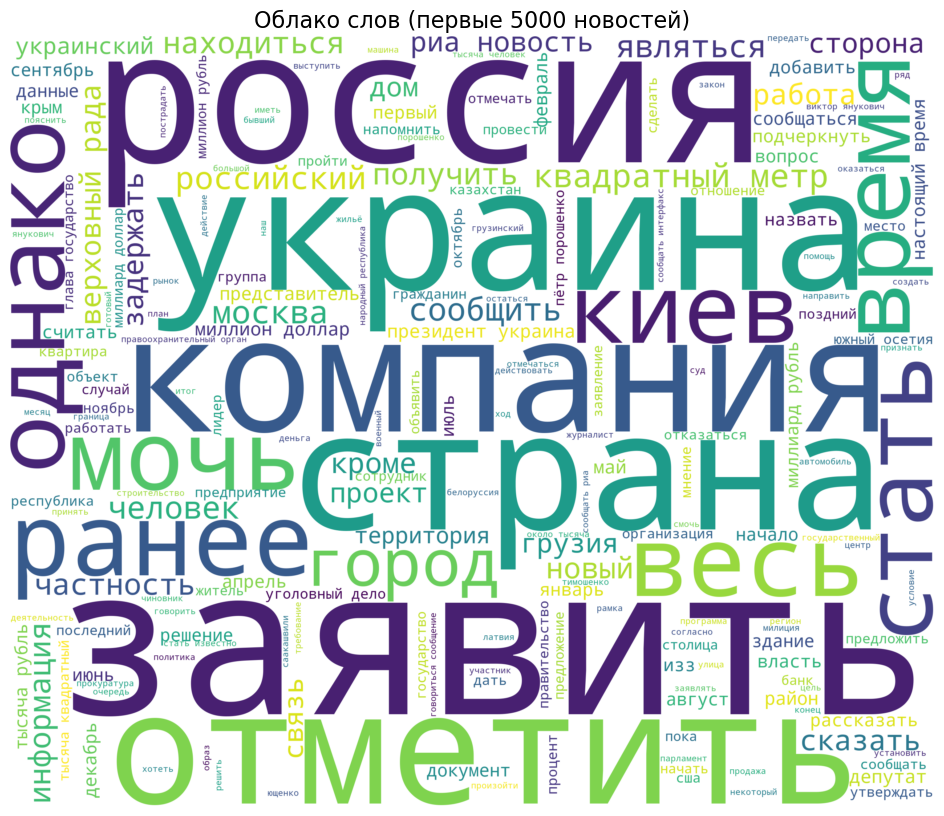

In [41]:
corpus_sample = get_corpus(df_short['tokenize_text'].head(5000).values)
procWordCloud = get_wordCloud(corpus_sample)

plt.figure(figsize=(16, 10))
plt.imshow(procWordCloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов (первые 5000 новостей)', fontsize=16)
plt.show()

In [42]:
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

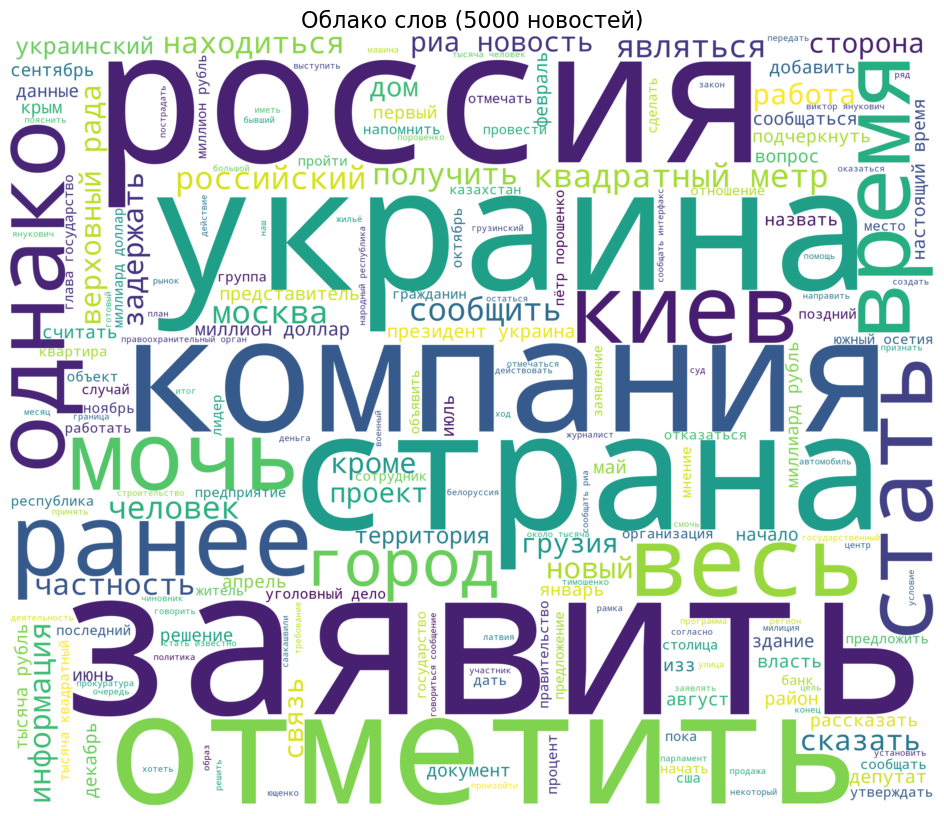

In [43]:
corpus = df_short['tokenize_text'].head(5000).tolist()
procWordCloud = get_wordCloud(corpus)

plt.figure(figsize=(16, 10))
plt.imshow(procWordCloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов (5000 новостей)', fontsize=16)
plt.show()

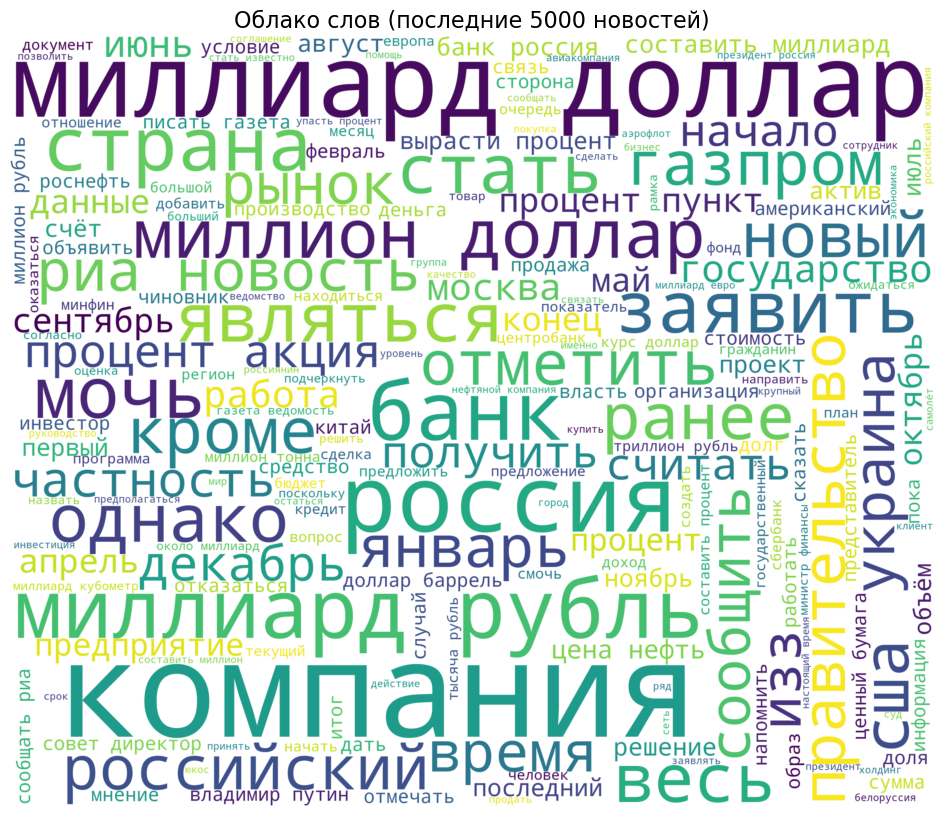

In [44]:
corpus = df_short['tokenize_text'].tail(5000).tolist()
procWordCloud = get_wordCloud(corpus)

plt.figure(figsize=(16, 10))
plt.imshow(procWordCloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов (последние 5000 новостей)', fontsize=16)
plt.show()

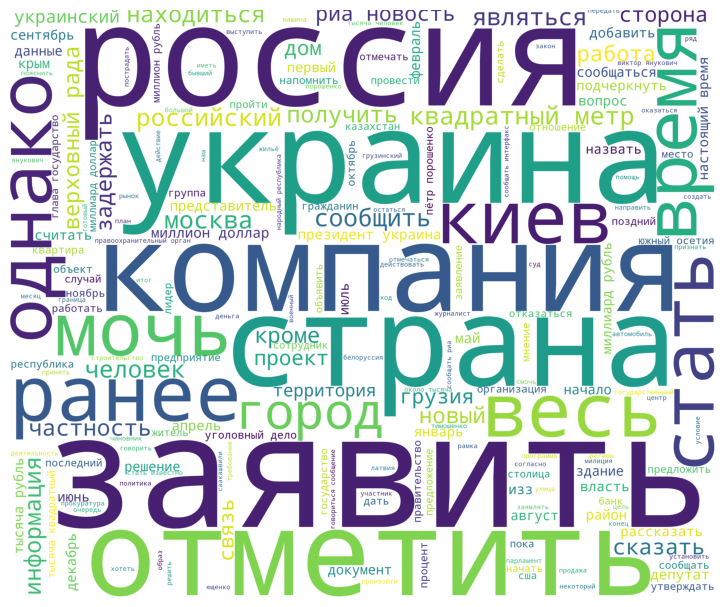

In [45]:
corpus = df_short['tokenize_text'].head(5000).tolist()
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.show()

In [46]:
df_short.head()

,title,text,topic,corpus,prep_text,text_lemm,tokenize_text
0,СП «Роснефти» и Statoil начало бурение скважин...,Совместное предприятие «Роснефти» и Statoil AS...,Бизнес,СП «Роснефти» и Statoil начало бурение скважин...,сп «роснефти» и statoil начало бурение скважин...,роснефть statoil начало бурение скважина охотс...,роснефть statoil начало бурение скважина охотс...
1,Минпромторг завернул проект «Ростеха» по испол...,Министерство промышленности и торговли России ...,Бизнес,Минпромторг завернул проект «Ростеха» по испол...,минпромторг завернул проект «ростеха» по испол...,минпромторг завернуть проект ростех исполнение...,минпромторг завернуть проект ростех исполнение...
2,Россия и Польша договорились о разрешениях на ...,Транспортные власти России и Польши предварите...,Бизнес,Россия и Польша договорились о разрешениях на ...,россия и польша договорились о разрешениях на ...,россия польша договориться разрешение автопере...,россия польша договориться разрешение автопере...
3,Nissan отзовет в России почти семь тысяч кросс...,«Ниссан Мэнуфэкчуринг Рус» (официальный предст...,Бизнес,Nissan отзовет в России почти семь тысяч кросс...,nissan отзовет в россии почти семь тысяч кросс...,nissan отозвать россия почти семь тысяча кросс...,nissan отозвать россия семь тысяча кроссовер н...
4,Москва и Киев договорились о продлении транзит...,Российская и украинская стороны приняли соглас...,Бизнес,Москва и Киев договорились о продлении транзит...,москва и киев договорились о продлении транзит...,москва киев договориться продление транзит фев...,москва киев договориться продление транзит фев...


*Облака слов показывают доминирование двух тем: геополитики (Россия, Украина) и экономики. В последних новостях фокус смещается с политических заявлений на финансы (доллар, миллиард, Газпром). Также данные требуют дополнительной очистки от стоп-слов и глаголов-связок, которые занимают место в топе.*

# Векторизация текстовых данных

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
count_vec = CountVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3), analyzer='word')
count_matrix = count_vec.fit_transform(df_short['tokenize_text'])

feature_names = count_vec.get_feature_names_out()

In [48]:
len(count_vec.vocabulary_)

5000

In [49]:
count_matrix.shape

(42749, 5000)

In [50]:
feature_names

array(['afp', 'agence', 'agence francepresse', ..., 'ярославский',
       'яценюк', 'ящик'], dtype=object)

### TF-IDF

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,         
    min_df=3,            
    max_features=5000,   
    ngram_range=(1, 3),  
    analyzer='word'
)

In [52]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df_short['tokenize_text'])

In [53]:
tfidf_matrix.shape

(42749, 5000)

In [54]:
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3354832 stored elements and shape (42749, 5000)>
  Coords	Values
  (0, 2903)	0.084382149688141
  (0, 4151)	0.0711733687309399
  (0, 2308)	0.08678719070481555
  (0, 2272)	0.07967984773100924
  (0, 2526)	0.07529993622923363
  (0, 833)	0.08276972641216182
  (0, 2315)	0.08559781634723737
  (0, 4661)	0.04386474155863752
  (0, 3733)	0.03339879647254169
  (0, 3210)	0.07422262878050129
  (0, 4167)	0.0630048730739018
  (0, 4046)	0.05620478131930907
  (0, 3373)	0.0718311897437541
  (0, 3852)	0.07288243879520298
  (0, 2781)	0.07493116910680107
  (0, 2918)	0.05503556661740442
  (0, 2833)	0.054133274843360314
  (0, 1954)	0.08002945590644495
  (0, 2609)	0.057181927130024235
  (0, 2066)	0.07052433928006753
  (0, 3836)	0.06888093979250363
  (0, 3500)	0.06509628428028275
  (0, 4458)	0.0655868435098611
  (0, 3246)	0.08007380243088981
  (0, 4996)	0.06886161580068077
  :	:
  (42748, 2995)	0.10727980204665852
  (42748, 1500)	0.08441825403063002


In [55]:
tfidf_vectorizer.get_feature_names_out()[1165:1175]

array(['жертва', 'жестокий', 'живой', 'животное', 'жизнь', 'жилищный',
       'жилой', 'жилой дом', 'жилой комплекс', 'жильё'], dtype=object)

# Тематическое моделирование

In [56]:
!pip install --upgrade scipy gensim

In [57]:
import gensim

In [58]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    return tokens

In [59]:
df_short['tokenize_text3'] = [tokenize2(text) for text in df_short['tokenize_text']]

In [60]:
gensim_dictionary = gensim.corpora.Dictionary(df_short['tokenize_text3'])
gensim_dictionary.filter_extremes(no_above=0.1, no_below=15)
gensim_dictionary.compactify()

In [61]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df_short['tokenize_text3']]

In [62]:
df_short.head()

,title,text,topic,corpus,prep_text,text_lemm,tokenize_text,tokenize_text3
0,СП «Роснефти» и Statoil начало бурение скважин...,Совместное предприятие «Роснефти» и Statoil AS...,Бизнес,СП «Роснефти» и Statoil начало бурение скважин...,сп «роснефти» и statoil начало бурение скважин...,роснефть statoil начало бурение скважина охотс...,роснефть statoil начало бурение скважина охотс...,"[роснефть, statoil, начало, бурение, скважина,..."
1,Минпромторг завернул проект «Ростеха» по испол...,Министерство промышленности и торговли России ...,Бизнес,Минпромторг завернул проект «Ростеха» по испол...,минпромторг завернул проект «ростеха» по испол...,минпромторг завернуть проект ростех исполнение...,минпромторг завернуть проект ростех исполнение...,"[минпромторг, завернуть, проект, ростех, испол..."
2,Россия и Польша договорились о разрешениях на ...,Транспортные власти России и Польши предварите...,Бизнес,Россия и Польша договорились о разрешениях на ...,россия и польша договорились о разрешениях на ...,россия польша договориться разрешение автопере...,россия польша договориться разрешение автопере...,"[россия, польша, договориться, разрешение, авт..."
3,Nissan отзовет в России почти семь тысяч кросс...,«Ниссан Мэнуфэкчуринг Рус» (официальный предст...,Бизнес,Nissan отзовет в России почти семь тысяч кросс...,nissan отзовет в россии почти семь тысяч кросс...,nissan отозвать россия почти семь тысяча кросс...,nissan отозвать россия семь тысяча кроссовер н...,"[nissan, отозвать, россия, семь, тысяча, кросс..."
4,Москва и Киев договорились о продлении транзит...,Российская и украинская стороны приняли соглас...,Бизнес,Москва и Киев договорились о продлении транзит...,москва и киев договорились о продлении транзит...,москва киев договориться продление транзит фев...,москва киев договориться продление транзит фев...,"[москва, киев, договориться, продление, транзи..."


In [63]:
corpus

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 5),
  (4, 1),
  (5, 4),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 3),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 5),
  (23, 1),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 2),
  (28, 1),
  (29, 1),
  (30, 2),
  (31, 1),
  (32, 1),
  (33, 4),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 2),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 2),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 2),
  (47, 1),
  (48, 1),
  (49, 2),
  (50, 1),
  (51, 1),
  (52, 8),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 1),
  (57, 6),
  (58, 1),
  (59, 3),
  (60, 1),
  (61, 1),
  (62, 2),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 2),
  (70, 4),
  (71, 3),
  (72, 1),
  (73, 1)],
 [(49, 6),
  (66, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 1),
  (82, 1),
  (83, 1),
  (84, 1),
  (85, 1),
  (86, 1),
  (87, 1),
  (88, 1),
  (89, 1

In [64]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [65]:
lda_20.print_topics()

[(0,
  '0.005*"банк" + 0.004*"миллиард" + 0.004*"закон" + 0.003*"федеральный" + 0.003*"директор" + 0.003*"система" + 0.003*"совет" + 0.003*"средство" + 0.003*"право" + 0.003*"проект"'),
 (1,
  '0.005*"the" + 0.005*"игра" + 0.004*"дом" + 0.004*"проект" + 0.004*"картина" + 0.003*"продажа" + 0.003*"появиться" + 0.003*"самый" + 0.003*"выйти" + 0.003*"режиссёр"'),
 (2,
  '0.008*"украина" + 0.006*"выборы" + 0.005*"партия" + 0.005*"министр" + 0.005*"лидер" + 0.004*"вопрос" + 0.004*"путин" + 0.003*"государство" + 0.003*"украинский" + 0.003*"отношение"'),
 (3,
  '0.014*"миллиард" + 0.009*"рынок" + 0.009*"цена" + 0.007*"нефть" + 0.007*"банк" + 0.006*"акция" + 0.006*"рост" + 0.005*"газ" + 0.005*"объём" + 0.005*"евро"'),
 (4,
  '0.006*"задержать" + 0.005*"полиция" + 0.005*"погибнуть" + 0.004*"самолёт" + 0.004*"район" + 0.004*"пострадать" + 0.003*"убийство" + 0.003*"уголовный" + 0.003*"область" + 0.003*"дом"'),
 (5,
  '0.007*"учёный" + 0.006*"военный" + 0.005*"система" + 0.004*"ракета" + 0.003*"ира

In [66]:
from sklearn.decomposition import LatentDirichletAllocation

In [67]:
n_topics = 5
n_top_words = 8
count_matrix_small = count_matrix[:3000]

print("\n" + "="*60)
print("LDA на 3000 текстов")
print("="*60)

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=10)
lda.fit(count_matrix_small)

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA на 3000 текстов
Тема 1:
дело задержать суд сообщать человек уголовный грузия бывший

Тема 2:
человек киргизия республика сообщать область военный погибнуть украинский

Тема 3:
россия украина российский газ страна территория сторона эстония

Тема 4:
украина президент страна украинский заявить глава россия депутат

Тема 5:
компания процент миллион россия миллиард рубль российский доллар



- Тема 1: Правосудие и происшествия
- Тема 2: Военная тематика и СНГ 
- Тема 3: Геополитика и энергетика 
- Тема 4: Политика и власть
- Тема 5: Экономика и финансы как по другому выделить заголовки в юпитер файле

In [68]:
!pip install pyLDAvis

In [69]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [70]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [71]:
pyLDAvis.enable_notebook()

In [72]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.020801  0.155072       1        1  20.191623
2      0.006403  0.033526       2        1  16.442271
1     -0.056263 -0.020368       3        1  15.646463
0      0.086888 -0.035752       4        1  14.875836
5      0.044536  0.074999       5        1  12.109232
3      0.125565 -0.147414       6        1  10.837994
6     -0.227929 -0.060063       7        1   9.896580, topic_info=           Term         Freq        Total Category  logprob  loglift
3941       матч  6401.000000  6401.000000  Default  30.0000  30.0000
503    миллиард  9911.000000  9911.000000  Default  29.0000  29.0000
6171    сборная  4644.000000  4644.000000  Default  28.0000  28.0000
2226    команда  5108.000000  5108.000000  Default  27.0000  27.0000
3955  чемпионат  3883.000000  3883.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
4437    сыграть  1098.363099  1849.798605   Topic7  -5.9340   1.7917
882      пройти  1349.152365  4924.960503   Topic7  -5.7283   1.0181
1027     третий  1179.403394  3649.272624   Topic7  -5.8628   1.1835
1000      выйти  1139.009958  4529.022510   Topic7  -5.8976   0.9326
485     главный  1119.339306  4511.158445   Topic7  -5.9151   0.9192

[657 rows x 6 columns], token_table=       Topic      Freq        Term
term                              
16783      3  0.975307  activision
16643      4  0.983785      altimo
16385      3  0.008844         amd
16385      4  0.946295         amd
16385      6  0.035376         amd
...      ...       ...         ...
7158       4  0.029853    янукович
7158       5  0.044779    янукович
7158       6  0.018125    янукович
7158       7  0.020257    янукович
16768      5  0.975409        ящер

[3347 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 3, 2, 1, 6, 4, 7])

In [73]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

texts_for_coherence = df_short['tokenize_text'].sample(n=5000, random_state=42).apply(lambda x: x.split()).tolist()
dictionary = Dictionary(texts_for_coherence)

topic_words = []
for topic in lda.components_:
    top_words_idx = topic.argsort()[:-11:-1]
    topic_words.append([feature_names[i] for i in top_words_idx])

coherence_model = CoherenceModel(topics=topic_words,
                                 texts=texts_for_coherence,
                                 dictionary=dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.542367486538424


In [74]:
from sklearn.decomposition import LatentDirichletAllocation

In [75]:
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: новый, система, учёный, время, мочь, первый, сша, игра, работа, компания
Topic 1: суд, дело, задержать, уголовный, сотрудник, сообщать, бывший, убийство, обвинение, полиция
Topic 2: матч, команда, сборная, чемпионат, россия, клуб, мир, игра, первый, счёт
Topic 3: человек, сообщать, погибнуть, произойти, город, время, находиться, самолёт, военный, данные
Topic 4: процент, компания, доллар, рубль, миллиард, миллион, россия, банк, российский, рынок
Topic 5: россия, президент, украина, заявить, страна, глава, российский, выборы, министр, украинский
Topic 6: тысяча, the, стать, компания, новый, миллион, сообщать, сайт, время, дом


In [76]:
from sklearn.decomposition import NMF 

In [77]:

nmf_model = NMF(n_components=5, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: человек, дело, задержать, полиция, погибнуть, произойти, взрыв, суд, сотрудник, город
Topic 1: процент, доллар, рубль, миллиард, компания, миллион, банк, рынок, миллиард доллар, цена
Topic 2: матч, сборная, команда, чемпионат, клуб, счёт, тренер, игра, сборная россия, турнир
Topic 3: украина, россия, президент, страна, глава, российский, заявить, путин, выборы, украинский
Topic 4: новый, the, компания, игра, картина, стать, первый, проект, американский, работа


In [78]:
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: человек, дело, задержать, полиция, суд, произойти, взрыв, сотрудник, убийство, погибнуть
Topic 1: доллар, миллиард, компания, миллион, рубль, банк, миллиард доллар, миллион доллар, миллиард рубль, акция
Topic 2: матч, сборная, команда, чемпионат, клуб, счёт, тренер, игра, сборная россия, турнир
Topic 3: украина, президент, россия, страна, глава, заявить, путин, украинский, выборы, российский
Topic 4: the, новый, картина, игра, стать, роль, режиссёр, первый, выйти, работа
Topic 5: самолёт, военный, истребитель, полёт, аэропорт, сша, ракета, ввс, борт, вертолёт
Topic 6: процент, цена, индекс, рост, рынок, нефть, рубль, вырасти, пункт, процент пункт


In [79]:
import warnings
import numpy as np
warnings.filterwarnings('ignore')
X_topics_nmf = nmf_model.fit_transform(tfidf_matrix)

date_text_only['topic_nmf'] = np.argmax(X_topics_nmf, axis=1)

In [80]:
date_text_only.head(10)

,tokenize_text,topic_nmf
0,роснефть statoil начало бурение скважина охотс...,1
1,минпромторг завернуть проект ростех исполнение...,3
2,россия польша договориться разрешение автопере...,3
3,nissan отозвать россия семь тысяча кроссовер н...,1
4,москва киев договориться продление транзит фев...,3
5,издатель пожаловаться фас минобрнауки ассоциац...,3
6,продажа автоваз май упасть процент май автоваз...,6
7,укртрансгаз впервые закупить газ электронный т...,1
8,миллер предложить европа построить трубопровод...,3
9,миллер подтвердить информация газовый договорё...,1


In [81]:
date_text_only['topic_nmf'].value_counts()

topic_nmf
4    10604
3     9792
0     6577
1     5036
5     4242
2     3945
6     2553
Name: count, dtype: int64

In [82]:
n_topics = 3

nmf_transformed = nmf_model.transform(tfidf_matrix)

print("\nТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:\n")
for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f"Тема {topic_idx + 1}:")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        title = date_text_only.iloc[doc_idx]['tokenize_text']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {title[:80]}... (уверенность: {score:.3f})")
    print()


ТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:

Тема 1:
   1. областной центр запад казахстан произойти перестрелка актоба административный це... (уверенность: 0.078)
   2. годовщина взрыв пушкинский площадь генпрокуратура продлевать срок следствие гене... (уверенность: 0.076)
   3. задержать напасть полицейский москва мужчина москва задержать мужчина напасть но... (уверенность: 0.073)

Тема 2:
   1. объём мировой рынок финансовый технология составить миллиард доллар рынок финанс... (уверенность: 0.139)
   2. израильский бизнесмен вложиться курорт ставрополье девелоперский компания afi de... (уверенность: 0.135)
   3. citigroup договориться продажа японский брокер американский банк citigroup догов... (уверенность: 0.131)

Тема 3:
   1. александр радулов пригласить сборная россия форвард клуб нхл нэшвилл предаторс а... (уверенность: 0.148)
   2. минифутбольный чемпионат европа россия одержать второй победа сборная россия мин... (уверенность: 0.140)
   3. чемпионат европа баскетбол россия начало победа 

Анализ результатов тематического моделирования
- Тема 1: Происшествия и криминал (уверенность ~0.07-0.08)
Перестрелки, взрывы, задержания
География: Казахстан (Актоба), Москва
Низкая уверенность модели указывает на разнородность темы
- Тема 2: Финансы и бизнес (уверенность ~0.13-0.14)
Мировые рынки, технологии, инвестиции
Банковский сектор (Citigroup)
Более высокая уверенность — тема лучше сгруппирована
- Тема 3: Спорт (уверенность ~0.14)
Хоккей (Радулов, НХЛ)
Футбол, баскетбол
Чемпионаты Европы, сборная России
Самая четкая тема с наивысшей уверенностью

In [83]:
from sklearn.decomposition import TruncatedSVD

In [84]:
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix)

for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: россия, компания, процент, доллар, российский, человек, миллион, время, сообщать, президент
Topic 1: процент, доллар, рубль, миллиард, компания, миллион, банк, миллиард доллар, цена, рынок
Topic 2: матч, сборная, команда, чемпионат, процент, игра, клуб, счёт, доллар, тренер
Topic 3: украина, президент, россия, путин, украинский, выборы, страна, глава, российский, министр
Topic 4: рубль, дело, матч, процент, задержать, суд, уголовный, сборная, москва, уголовный дело
Topic 5: самолёт, процент, погибнуть, военный, взрыв, человек, произойти, сша, боевик, вертолёт
Topic 6: процент, выборы, индекс, человек, рост, пункт, президент, процент пункт, партия, вырасти


# Классификация

In [85]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(date_text_only['tokenize_text'], date_text_only['topic_nmf'], 
                                                      test_size=0.3, 
                                                      random_state=0)

In [86]:
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [87]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [88]:
model_lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
model_lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

In [89]:
y_pred = model_lr.predict(X_test_tfidf)

In [90]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1981
           1       0.95      0.93      0.94      1516
           2       0.98      0.97      0.98      1177
           3       0.95      0.97      0.96      2938
           4       0.95      0.97      0.96      3244
           5       0.96      0.90      0.93      1229
           6       0.98      0.88      0.93       740

    accuracy                           0.95     12825
   macro avg       0.96      0.94      0.95     12825
weighted avg       0.95      0.95      0.95     12825



Модель показывает высокое качество классификации: общая точность — 95%. Средневзвешенный F1-скор также составляет 0.95, что говорит о стабильной работе по всем категориям.

In [91]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [92]:
y_pred = model_rf.predict(X_test_tfidf)

In [93]:
print(classification_report(y_test, y_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1981
           1       0.86      0.84      0.85      1516
           2       0.94      0.97      0.95      1177
           3       0.83      0.92      0.87      2938
           4       0.89      0.87      0.88      3244
           5       0.93      0.73      0.82      1229
           6       0.95      0.73      0.83       740

    accuracy                           0.87     12825
   macro avg       0.89      0.85      0.87     12825
weighted avg       0.88      0.87      0.87     12825



Модель показывает приемлемое, но не отличное качество: общая точность — 87%.

In [94]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [95]:
y_pred = model_knn.predict(X_test_tfidf)

In [96]:
print(classification_report(y_test, y_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77      1981
           1       0.70      0.75      0.72      1516
           2       0.89      0.94      0.92      1177
           3       0.75      0.76      0.76      2938
           4       0.85      0.80      0.82      3244
           5       0.78      0.76      0.77      1229
           6       0.77      0.69      0.72       740

    accuracy                           0.79     12825
   macro avg       0.79      0.78      0.78     12825
weighted avg       0.79      0.79      0.79     12825



Модель показывает 79% точности — это на 16 процентных пунктов хуже первой и на 8% хуже второй.

## Сохранение моделей

In [257]:
import pickle

with open('model_lr_news1.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

In [258]:
with open('vectorizer_news1.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

In [259]:
date_text_only.to_csv('date_text_only_news1.csv')

In [260]:
date_text_only.head()

,tokenize_text,topic_nmf
0,роснефть statoil начало бурение скважина охотс...,1
1,минпромторг завернуть проект ростех исполнение...,3
2,россия польша договориться разрешение автопере...,3
3,nissan отозвать россия семь тысяча кроссовер н...,1
4,москва киев договориться продление транзит фев...,3


## Проверка модели

In [261]:
import pickle
import joblib
import pandas as pd
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.feature_extraction.text import TfidfVectorizer

In [262]:
with open('model_lr_news1.pkl', 'rb') as file:
    model = pickle.load(file)

with open('vectorizer_news1.pkl', 'rb') as file:
    vectorizer = pickle.load(file)

In [263]:
def fun_punctuation_text(text):
    text = text.lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = ''.join([i if not i.isdigit() else '' for i in text])
    text = ''.join([i if i.isalpha() else ' ' for i in text])
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub('[a-z]', '', text, flags=re.I)
    st = '❯\xa0'
    text = ''.join([ch if ch not in st else ' ' for ch in text])
    return text

In [280]:
def fun_tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = ' '.join(tokens)
    return text

In [281]:
def fun_lemmatizing_text(text):
    tokens = word_tokenize(text)
    res = list()
    for word in tokens:
        p = pymorphy3.MorphAnalyzer(lang='ru').parse(word)[0]
        res.append(p.normal_form)  
    text = " ".join(res)
    return text

In [282]:
t1 = "Оптовая цена электричества в США выросла на 75% за год. Причина — ИИ-дата-центры"

In [283]:
t2 = "Правительство Мальты и OpenAI договорились о бесплатном доступе к ChatGPT Plus для всех жителей"

In [284]:
t3 = "Школьникам нельзя ссылаться на аниме, видеоигры, фанфики и комиксы на ЕГЭ"

In [285]:
t4 = "Синьоры исчезнут из-за ИИ, а зарплаты упадут? Рассказываем, что предрекают рынку эксперты"

In [286]:
t5 = "В GitLab предупредили о сокращении штата в рамках перехода к «эпохе ИИ-агентов»"

In [287]:
def predict_topic(text):
    text = fun_punctuation_text(text)
    text = fun_lemmatizing_text(text)
    text = fun_tokenize(text)
    text_vectorized = vectorizer.transform([text])
    prediction = model.predict(text_vectorized)
    probabilities = model.predict_proba(text_vectorized)
    return prediction, probabilities

In [113]:
prediction, probabilities = predict_topic(t2)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 3
Вероятности: [[0.04 0.   0.   0.54 0.4  0.01 0.01]]


In [114]:
prediction, probabilities = predict_topic(t3)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 4
Вероятности: [[0.03 0.01 0.01 0.03 0.83 0.09 0.  ]]


In [115]:
prediction, probabilities = predict_topic(t4)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 4
Вероятности: [[0.04 0.15 0.   0.02 0.67 0.03 0.09]]


In [116]:
prediction, probabilities = predict_topic(t5)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 4
Вероятности: [[0.04 0.   0.02 0.05 0.81 0.05 0.03]]


### Вывод по классификации:
модель устойчиво классифицирует новые новости. Высокая уверенность (>80%) говорит о хорошем качестве. Низкая (50-60%) — естественная ситуация для текстов со смешанной тематикой.

## 6. Парсинг данных 

In [117]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def parse_habr_news(count_needed=500):
    headers = {'User-Agent': 'Mozilla/5.0'}
    base_url = 'https://habr.com/ru/news/page'
    parsed_data = []
    page = 1
    
    print(f"Начинаю сбор {count_needed} новостей...")
    
    while len(parsed_data) < count_needed:
        url = f"{base_url}{page}/"
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            break
            
        soup = BeautifulSoup(response.text, 'html.parser')
        articles = soup.find_all('article', class_='tm-articles-list__item')
        
        for article in articles:
            if len(parsed_data) >= count_needed:
                break
                
            try:
                title = article.find('a', class_='tm-title__link').text.strip()
                link = 'https://habr.com' + article.find('a', class_='tm-title__link')['href']
                snippet = article.find('div', class_='article-formatted-body').text.strip()
                
                parsed_data.append({
                    'title': title,
                    'text': snippet, 
                    'url': link
                })
            except AttributeError:
                continue
        
        print(f"Собрано: {len(parsed_data)}")
        page += 1
        time.sleep(1)
        
    return pd.DataFrame(parsed_data)

new_news_df = parse_habr_news(500)
new_news_df.to_csv('parsed_news.csv', index=False)
print("Готово! Файл 'parsed_news.csv' сохранен.")

Начинаю сбор 500 новостей...
Собрано: 20
Собрано: 40
Собрано: 60
Собрано: 80
Собрано: 100
Собрано: 120
Собрано: 140
Собрано: 160
Собрано: 180
Собрано: 200
Собрано: 220
Собрано: 240
Собрано: 260
Собрано: 280
Собрано: 300
Собрано: 320
Собрано: 340
Собрано: 360
Собрано: 380
Собрано: 400
Собрано: 420
Собрано: 440
Собрано: 460
Собрано: 480
Собрано: 500
Готово! Файл 'parsed_news.csv' сохранен.


Провели парсинг данных с сайтах Habr, вытаскивали по ссылкам статью и с определенный статьи вытаскиваем 3 признака для образования датасета.

In [118]:
df = pd.read_csv("parsed_news.csv")
df.head()

,title,text,url
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...,https://habr.com/ru/news/1039116/
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н...",https://habr.com/ru/news/1039114/
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...,https://habr.com/ru/news/1039112/
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро...",https://habr.com/ru/news/1039110/
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...,https://habr.com/ru/news/1039104/


Просмотрели, какокй датасет собрался

In [119]:
df

,title,text,url
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...,https://habr.com/ru/news/1039116/
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н...",https://habr.com/ru/news/1039114/
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...,https://habr.com/ru/news/1039112/
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро...",https://habr.com/ru/news/1039110/
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...,https://habr.com/ru/news/1039104/
...,...,...,...
495,СМИ: «МОК приостанавливает работу комиссии по ...,Международный олимпийский комитет (МОК) планир...,https://habr.com/ru/news/1035274/
496,«Группа Астра» запускает Astra Cloud на россий...,«Группа Астра» представила Astra Cloud на росс...,https://habr.com/ru/companies/astralinux/news/...
497,На хакатоне CodeStorm 2026 определился победит...,"Сегодня, 14 мая, на площадке Казань Экспо сост...",https://habr.com/ru/companies/technokratos/new...
498,Microsoft исправила ошибку в Windows Autopatch...,"Microsoft решила проблему в Windows Autopatch,...",https://habr.com/ru/news/1035254/


In [120]:
pip install pymorphy3

Note: you may need to restart the kernel to use updated packages.


In [121]:
df.drop('url', axis=1, inplace=True)

Посчитали, что поле url не надо для дальнейшей работы, так что убираем.

In [122]:
df.to_csv('parsed_news2.csv', index=False)

In [123]:
df.head()

,title,text
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н..."
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро..."
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...


In [124]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

import re
import nltk
import pymorphy3

import gensim

import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [125]:
df = pd.read_csv("parsed_news2.csv")
df.head()

,title,text
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н..."
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро..."
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...


In [126]:
df['text'][0]

'Из\xa0законопроекта о\xa0поддержке «Почты России» убрали требование к\xa0маркетплейсам, попавшим в\xa0реестр цифровых платформ, открывать пункты выдачи заказов в\xa0отделениях почты\xa0либо доставлять товары напрямую туда. Об\xa0этом\xa0сообщают источники РБК. Также из\xa0документа исключили требование к\xa0компаниям, занимающимся доставкой, получать\xa0лицензию почтового оператора.'

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   500 non-null    object
 1   text    500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


In [128]:
df['corpus'] = (df['title'].fillna('') + ' ' + 
                df['text'].fillna(''))

### Предобработка текста

In [129]:
st = '\xa0—'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [130]:
df['prep_text']= [remove_othersymbol(text.lower()) for text in df['corpus']]

In [131]:
df['prep_text'][0]

'«почта россии» отказалась от идеи обязать маркетплейсы и службы доставки работать через свою инфраструктуру из законопроекта о поддержке «почты россии» убрали требование к маркетплейсам, попавшим в реестр цифровых платформ, открывать пункты выдачи заказов в отделениях почты либо доставлять товары напрямую туда. об этом сообщают источники рбк. также из документа исключили требование к компаниям, занимающимся доставкой, получать лицензию почтового оператора.'

In [132]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [133]:
df['prep_text']= [remove_punctuation(text) for text in df['prep_text']]

In [134]:
df['prep_text'][0]

'«почта россии» отказалась от идеи обязать маркетплейсы и службы доставки работать через свою инфраструктуру из законопроекта о поддержке «почты россии» убрали требование к маркетплейсам попавшим в реестр цифровых платформ открывать пункты выдачи заказов в отделениях почты либо доставлять товары напрямую туда об этом сообщают источники рбк также из документа исключили требование к компаниям занимающимся доставкой получать лицензию почтового оператора'

In [135]:
df.head()

,title,text,corpus,prep_text
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...,«Почта России» отказалась от идеи обязать марк...,«почта россии» отказалась от идеи обязать марк...
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н...",Один из разработчиков Anthropic перед свадьбой...,один из разработчиков anthropic перед свадьбой...
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...,Цены на электронику в США резко возросли из‑за...,цены на электронику в сша резко возросли из‑за...
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро...",Mozilla представляет втроенный в браузер VPN и...,mozilla представляет втроенный в браузер vpn и...
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...,Объём краудфандинга Star Citizen превысил $1 м...,объём краудфандинга star citizen превысил 1 мл...


In [136]:
import nltk
nltk.download('stopwords')
russian_stopwords = stopwords.words("russian") 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Азалия\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [137]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный','фильм', 'кино', 'смотреть', 'год', 'снят', 'рассказывает', 'история', 
                'оказывается', 'вдруг', 'наконец', 'также', 'который', 'который', 'этот', 'эта', 'это', 'эти', 'подписаться', 'каждый', 'просто', 'очень', 'назад', 
                'час назад', 'простой', 'март', 'привет хабр', 'то есть', 'подписаться', 'каждый', 'просто', 'очень', 'назад', 'час назад', 
                'простой', 'март', 'хороший', 'несколько', 'нужно', 'прямо', 'вместе', 'общий', 'разный', 'особый', 'целое', 'часть', 'результат', 'слово', 'порядок', 'подход', 'ответ', 
                'параметр', 'делегировать', 'требоваться', 'использование', 'час', 'день', 'понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье', 'число', 'сутки',
                'сегодняшний', 'банально', 'например', 'ия']) 

In [138]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Азалия\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [139]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [140]:
%%time
lemm_texts_list = []
for text in (df['prep_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 6.66 s
Wall time: 6.67 s


In [141]:
df.head()

,title,text,corpus,prep_text,text_lemm
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...,«Почта России» отказалась от идеи обязать марк...,«почта россии» отказалась от идеи обязать марк...,« почта россия » отказаться от идея обязать ма...
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н...",Один из разработчиков Anthropic перед свадьбой...,один из разработчиков anthropic перед свадьбой...,один из разработчик anthropic перед свадьба за...
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...,Цены на электронику в США резко возросли из‑за...,цены на электронику в сша резко возросли из‑за...,цена на электроника в сша резко возрасти из‑з ...
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро...",Mozilla представляет втроенный в браузер VPN и...,mozilla представляет втроенный в браузер vpn и...,mozilla представлять втроить в браузер vpn и 5...
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...,Объём краудфандинга Star Citizen превысил $1 м...,объём краудфандинга star citizen превысил 1 мл...,объём краудфандинг star citizen превысить 1 мл...


In [142]:
df['text_lemm'][0]

'« почта россия » отказаться от идея обязать маркетплейс и служба доставка работать через свой инфраструктура из законопроект о поддержка « почта россия » убрать требование к маркетплейс попасть в реестр цифровой платформа открывать пункт выдача заказ в отделение почта либо доставлять товар напрямую туда о это сообщать источник рбк также из документ исключить требование к компания заниматься доставка получать лицензия почтовый оператор'

In [143]:
def clean_textpub(text):
    text = re.sub(r'\b\w*\d\w*\b', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    return text

In [144]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(t) > 2]
    text = " ".join(tokens)
    return clean_textpub(text)

In [145]:
df['tokenize_text'] = [tokenize(text) for text in df['text_lemm']]

In [146]:
df.head()

,title,text,corpus,prep_text,text_lemm,tokenize_text
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...,«Почта России» отказалась от идеи обязать марк...,«почта россии» отказалась от идеи обязать марк...,« почта россия » отказаться от идея обязать ма...,почта россия отказаться идея обязать марке...
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н...",Один из разработчиков Anthropic перед свадьбой...,один из разработчиков anthropic перед свадьбой...,один из разработчик anthropic перед свадьба за...,разработчик anthropic свадьба закинуть claude ...
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...,Цены на электронику в США резко возросли из‑за...,цены на электронику в сша резко возросли из‑за...,цена на электроника в сша резко возрасти из‑з ...,цена электроника сша резко возрасти из з модул...
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро...",Mozilla представляет втроенный в браузер VPN и...,mozilla представляет втроенный в браузер vpn и...,mozilla представлять втроить в браузер vpn и 5...,mozilla представлять втроить браузер vpn тра...
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...,Объём краудфандинга Star Citizen превысил $1 м...,объём краудфандинга star citizen превысил 1 мл...,объём краудфандинг star citizen превысить 1 мл...,объём краудфандинг star citizen превысить мл...


In [147]:
df['tokenize_text'][0]

'  почта россия   отказаться идея обязать маркетплейс служба доставка работать инфраструктура законопроект поддержка   почта россия   убрать требование маркетплейс попасть реестр цифровой платформа открывать пункт выдача заказ отделение почта либо доставлять товар напрямую туда сообщать источник рбк документ исключить требование компания заниматься доставка получать лицензия почтовый оператор'

In [148]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [149]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

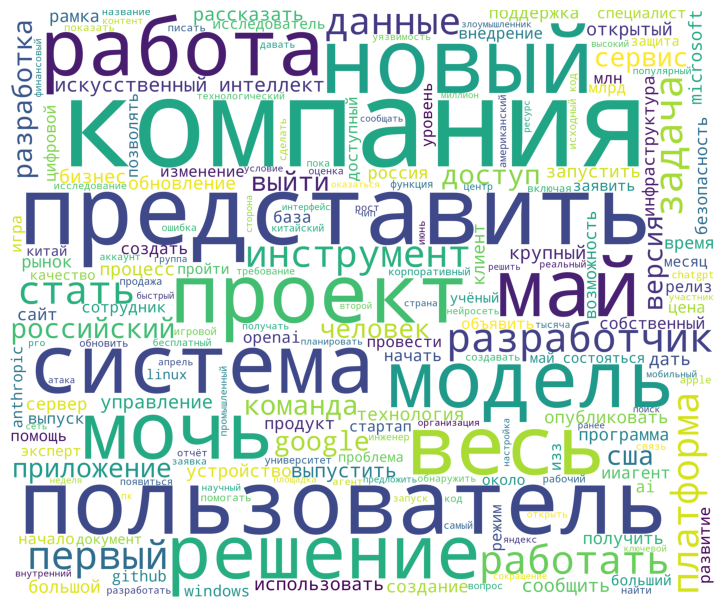

In [150]:
corpus = get_corpus(df['tokenize_text'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

In [151]:
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

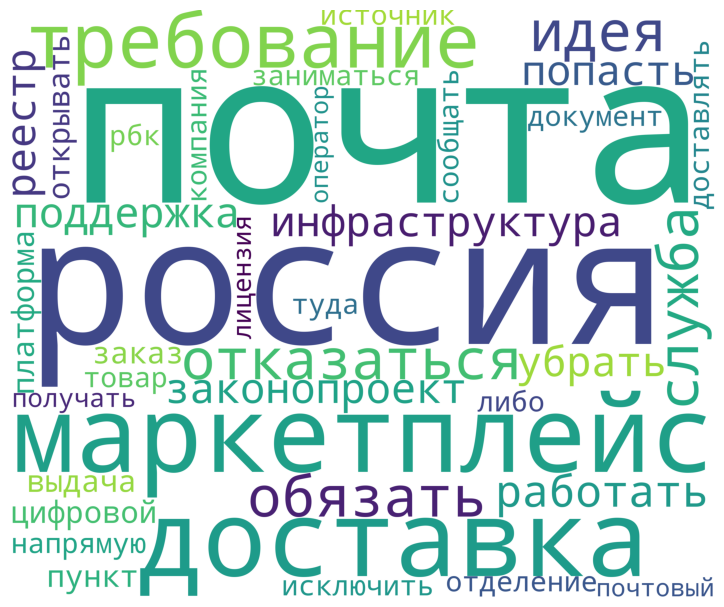

In [152]:
corpus = df['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

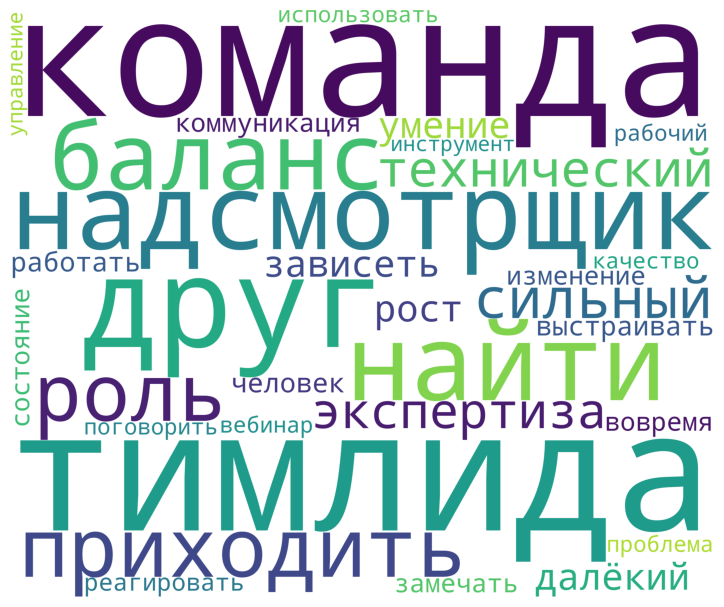

In [153]:
corpus = df['tokenize_text'][len(df)-1]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

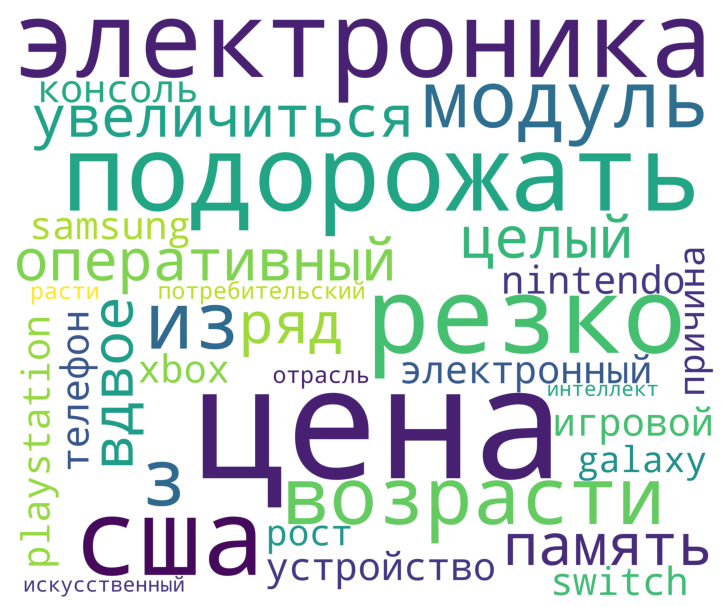

In [154]:
corpus = df['tokenize_text'][2]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show()

In [155]:
df.head()

,title,text,corpus,prep_text,text_lemm,tokenize_text
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...,«Почта России» отказалась от идеи обязать марк...,«почта россии» отказалась от идеи обязать марк...,« почта россия » отказаться от идея обязать ма...,почта россия отказаться идея обязать марке...
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н...",Один из разработчиков Anthropic перед свадьбой...,один из разработчиков anthropic перед свадьбой...,один из разработчик anthropic перед свадьба за...,разработчик anthropic свадьба закинуть claude ...
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...,Цены на электронику в США резко возросли из‑за...,цены на электронику в сша резко возросли из‑за...,цена на электроника в сша резко возрасти из‑з ...,цена электроника сша резко возрасти из з модул...
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро...",Mozilla представляет втроенный в браузер VPN и...,mozilla представляет втроенный в браузер vpn и...,mozilla представлять втроить в браузер vpn и 5...,mozilla представлять втроить браузер vpn тра...
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...,Объём краудфандинга Star Citizen превысил $1 м...,объём краудфандинга star citizen превысил 1 мл...,объём краудфандинг star citizen превысить 1 мл...,объём краудфандинг star citizen превысить мл...


## Векторизация текстовых данных

### Bag of words

In [156]:
count_vec = CountVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3), analyzer='word')
count_matrix = count_vec.fit_transform(df['tokenize_text'])

feature_names = count_vec.get_feature_names_out()

In [157]:
len(count_vec.vocabulary_)

1833

In [158]:
count_matrix.shape

(500, 1833)

In [159]:
feature_names

array(['agent', 'ai', 'aiагент', ..., 'япония', 'японский', 'ёмкость'],
      dtype=object)

### TF-IDF

In [160]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,         
    min_df=3,            
    max_features=5000,   
    ngram_range=(1, 3),  
    analyzer='word'
)

In [161]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenize_text'])

In [162]:
tfidf_matrix.shape

(500, 1833)

In [163]:
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13936 stored elements and shape (500, 1833)>
  Coords	Values
  (0, 966)	0.14011641414386816
  (0, 728)	0.11398966957926814
  (0, 1137)	0.12671492012174507
  (0, 515)	0.15468189006207217
  (0, 670)	0.06214976122550303
  (0, 456)	0.11896111177708148
  (0, 623)	0.13052238042347752
  (0, 1529)	0.12035229485050658
  (0, 851)	0.1662431587084682
  (0, 1645)	0.15468189006207217
  (0, 721)	0.1662431587084682
  (0, 500)	0.15468189006207217
  (0, 1312)	0.15468189006207217
  (0, 1015)	0.15988053343722974
  (0, 1082)	0.10205073187657794
  (0, 1763)	0.11398966957926814
  (0, 1380)	0.14647903941510665
  (0, 1657)	0.25342984024349013
  (0, 1665)	0.1662431587084682
  (0, 1101)	0.11075826113011593
  (0, 504)	0.1662431587084682
  (0, 606)	0.11075826113011593
  (0, 1318)	0.09422555028590657
  (0, 465)	0.30936378012414434
  (0, 1492)	0.12671492012174507
  :	:
  (498, 1704)	0.1710576028375506
  (498, 1400)	0.1956543389473016
  (499, 1540)	0.24350

In [164]:
tfidf_vectorizer.get_feature_names_out()[1165:1175]

array(['поскольку', 'последний', 'посмотреть', 'поставка', 'пострадать',
       'построение', 'потенциально', 'потенциальный', 'потеря',
       'потерять'], dtype=object)

# Тематическое моделирование

In [165]:
import gensim

In [166]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    return tokens

In [167]:
df['tokenize_text3'] = [tokenize2(text) for text in df['tokenize_text']]

In [168]:
gensim_dictionary = gensim.corpora.Dictionary(df['tokenize_text3'])
gensim_dictionary.filter_extremes(no_above=0.1, no_below=15)
gensim_dictionary.compactify()

In [169]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df['tokenize_text3']]

In [170]:
df.head()

,title,text,corpus,prep_text,text_lemm,tokenize_text,tokenize_text3
0,«Почта России» отказалась от идеи обязать марк...,Из законопроекта о поддержке «Почты России» уб...,«Почта России» отказалась от идеи обязать марк...,«почта россии» отказалась от идеи обязать марк...,« почта россия » отказаться от идея обязать ма...,почта россия отказаться идея обязать марке...,"[почта, россия, отказаться, идея, обязать, мар..."
1,Один из разработчиков Anthropic перед свадьбой...,"Разработчик Остин Лау рассказал, что женился н...",Один из разработчиков Anthropic перед свадьбой...,один из разработчиков anthropic перед свадьбой...,один из разработчик anthropic перед свадьба за...,разработчик anthropic свадьба закинуть claude ...,"[разработчик, anthropic, свадьба, закинуть, cl..."
2,Цены на электронику в США резко возросли из‑за...,В США резко увеличились цены на целый ряд элек...,Цены на электронику в США резко возросли из‑за...,цены на электронику в сша резко возросли из‑за...,цена на электроника в сша резко возрасти из‑з ...,цена электроника сша резко возрасти из з модул...,"[цена, электроника, сша, резко, возрасти, з, м..."
3,Mozilla представляет втроенный в браузер VPN и...,"В версии 149 Mozilla начала тестировать ""встро...",Mozilla представляет втроенный в браузер VPN и...,mozilla представляет втроенный в браузер vpn и...,mozilla представлять втроить в браузер vpn и 5...,mozilla представлять втроить браузер vpn тра...,"[mozilla, представлять, втроить, браузер, vpn,..."
4,Объём краудфандинга Star Citizen превысил $1 млрд,Объём краудфандинга научно-фантастической роле...,Объём краудфандинга Star Citizen превысил $1 м...,объём краудфандинга star citizen превысил 1 мл...,объём краудфандинг star citizen превысить 1 мл...,объём краудфандинг star citizen превысить мл...,"[объём, краудфандинг, star, citizen, превысить..."


In [171]:
corpus

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 2),
  (8, 1),
  (9, 1),
  (10, 2),
  (11, 1)],
 [(12, 1),
  (13, 1),
  (14, 2),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 2),
  (19, 1),
  (20, 1),
  (21, 1)],
 [(22, 1), (23, 1), (24, 1), (25, 2), (26, 1), (27, 3)],
 [(18, 1),
  (19, 1),
  (26, 1),
  (28, 1),
  (29, 4),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 2)],
 [(38, 2), (39, 1), (40, 2), (41, 1), (42, 1)],
 [(43, 1), (44, 1), (45, 2)],
 [(7, 1), (31, 2), (45, 2), (46, 2)],
 [(47, 2),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 1)],
 [(24, 1), (40, 1), (45, 2), (55, 1), (56, 1), (57, 4), (58, 1)],
 [(1, 1),
  (18, 1),
  (24, 1),
  (54, 2),
  (59, 3),
  (60, 1),
  (61, 1),
  (62, 1),
  (63, 1),
  (64, 2),
  (65, 1)],
 [(42, 1),
  (51, 1),
  (62, 1),
  (66, 3),
  (67, 1),
  (68, 2),
  (69, 1),
  (70, 1),
  (71, 1)],
 [(33, 1), (68, 2), (72, 2), (73, 2), (74, 1)],
 [(6, 1), (58,

In [172]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [173]:
from sklearn.decomposition import LatentDirichletAllocation

In [174]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(count_matrix)

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)
Тема 1:
компания платформа microsoft пользователь разработка управление приложение сервис код инструмент

Тема 2:
система компания данные приложение доступ уязвимость пользователь позволять учёный весь

Тема 3:
проект май версия выйти открытый релиз выпуск представить состояться модель

Тема 4:
github claude code мочь май компания модель процессор работа доступ

Тема 5:
компания млрд представить google май искусственный интеллект интеллект искусственный игра пользователь

Тема 6:
компания российский рубль сша весь бизнес рынок данные начало пользователь

Тема 7:
компания представить человек выпустить модель google новый искусственный искусственный интеллект интеллект



In [175]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [176]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [177]:
pyLDAvis.enable_notebook()

In [178]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.058715 -0.009270       1        1  17.031133
4      0.059122 -0.074571       2        1  16.679144
5     -0.293895  0.010923       3        1  15.874610
1     -0.000022  0.047368       4        1  15.793713
2      0.028362 -0.168008       5        1  13.041202
3      0.065933  0.182995       6        1  11.036637
6      0.081786  0.010563       7        1  10.543561, topic_info=               Term       Freq      Total Category  logprob  loglift
67           google  60.000000  60.000000  Default  30.0000  30.0000
145          openai  38.000000  38.000000  Default  29.0000  29.0000
94           выпуск  41.000000  41.000000  Default  28.0000  28.0000
102          github  44.000000  44.000000  Default  27.0000  27.0000
66               ai  52.000000  52.000000  Default  26.0000  26.0000
..              ...        ...        ...      ...      ...      ...
21        сотрудник   5.582978  27.119281   Topic7  -4.5472   0.6691
1    инфраструктура   6.817139  34.375574   Topic7  -4.3475   0.6317
61           задача  11.135723  63.065507   Topic7  -3.8568   0.5156
109       запустить   7.357438  43.716934   Topic7  -4.2712   0.4676
88         развитие   5.838509  32.466511   Topic7  -4.5025   0.5339

[285 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
66        1  0.114728         ai
66        2  0.019121         ai
66        5  0.248578         ai
66        6  0.592762         ai
12        1  0.034631  anthropic
...     ...       ...        ...
42        6  0.087163    человек
154       2  0.358355    эксперт
154       3  0.039817    эксперт
154       5  0.079634    эксперт
154       7  0.517624    эксперт

[710 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 5, 6, 2, 3, 4, 7])

In [179]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.301185980258666


In [180]:
from sklearn.decomposition import LatentDirichletAllocation

In [181]:
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: проект, код, открытый, компания, исходный, май, релиз, исходный код, версия, обновление
Topic 1: модель, задача, компания, работа, работать, новый, мочь, пользователь, приложение, человек
Topic 2: компания, linux, сша, искусственный интеллект, интеллект, искусственный, ядро, новый, данные, база
Topic 3: компания, github, сервер, данные, code, доступ, искусственный, искусственный интеллект, интеллект, клиент
Topic 4: компания, представить, ai, доступ, весь, первый, млрд, май, система, цифровой
Topic 5: управление, система, платформа, проект, май, компания, решение, версия, выпуск, разработчик
Topic 6: пользователь, chatgpt, openai, весь, запустить, представить, май, новый, первый, компания


In [182]:
from sklearn.decomposition import NMF

In [183]:
nmf_model = NMF(n_components=10, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: компания, российский, млрд, сша, рубль, россия, система, млн, бизнес, данные
Topic 1: проект, релиз, состояться, май состояться, выпуск, лицензия, выйти, открытый, версия, исходный
Topic 2: google, gemini, youtube, ai, io, обновить, flash, deepmind, пользователь, приложение
Topic 3: github, code, репозиторий, vs, внутренний, расширение, vs code, внутренний репозиторий, расширение vs, доступ
Topic 4: модель, задача, ai, работа, новый, процесс, команда, выпустить, claude, агент
Topic 5: openai, chatgpt, codex, anthropic, openai запустить, запустить, весь, финансовый, сооснователь, банковский
Topic 6: linux, представить, ядро, ядро linux, база, дистрибутив, выпуск, выйти, обновление, версия
Topic 7: искусственный, искусственный интеллект, интеллект, внедрение, spotify, технологический, представить, технология, компания, человек
Topic 8: приложение, сервер, магазин, магазин приложение, store, мобильный, дать, app store, app, apple
Topic 9: microsoft, windows, обновление, пользоват

In [184]:
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: компания, российский, сша, искусственный, интеллект, искусственный интеллект, развитие, система, технология, бизнес
Topic 1: проект, релиз, состояться, май состояться, лицензия, открытый, выйти, выпуск, код, исходный
Topic 2: google, приложение, пользователь, gemini, youtube, обновить, игровой, видео, apple, reddit
Topic 3: github, code, microsoft, репозиторий, доступ, внутренний, vs, расширение, vs code, внутренний репозиторий
Topic 4: модель, ai, задача, выпустить, новый, claude, процесс, работа, ииагент, pro
Topic 5: openai, chatgpt, codex, anthropic, openai запустить, весь, запустить, финансовый, сооснователь, банковский
Topic 6: linux, представить, ядро, база, обновление, выпуск, ядро linux, выйти, дистрибутив, версия


In [185]:
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("\nТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:\n")
for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f" Topic {topic_idx}")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        title = df.iloc[doc_idx]['title']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {title} (уверенность: {score:.3f})")
    print()


ТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:

 Topic 0
   1. США хотят финансировать экспорт своих AI-инструментов за рубеж (уверенность: 0.135)
   2. На форуме «ИИ – будущее сегодня» обсудят практику внедрения искусственного интеллекта (уверенность: 0.132)
   3. UserGate на ЦИПР 2026 рассказал о самых слабых местах для кибератак в ИТ‑инфраструктуре российских компаний (уверенность: 0.131)

 Topic 1
   1. Вышло обновление открытого проекта ForgeZero 1.9.0 — мультиплатформенного инструмента сборки для C и ассемблера (уверенность: 0.435)
   2. Вышла версия Kitty Terminal 0.47 (уверенность: 0.418)
   3. Выпуск открытого проекта Segra 1.5.0 для записи игр на ПК с Windows (уверенность: 0.406)

 Topic 2
   1. Вышла видеомодель Google Gemini Omni: «превратит что угодно во что угодно» (уверенность: 0.399)
   2. Google обновил иконки Workspace и не предупредил (уверенность: 0.369)
   3. Реддитор сделал из неисправного Google Pixel 8 игровую приставку для ретро-игр (уверенность: 0.356)

 Topic 3
   1. Масштаб

In [186]:
from sklearn.decomposition import TruncatedSVD

In [187]:
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix)

for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: проект, компания, представить, май, система, новый, версия, модель, код, выйти
Topic 1: проект, выпуск, релиз, выйти, состояться, май состояться, версия, windows, лицензия, обновление
Topic 2: google, приложение, пользователь, gemini, ai, модель, обновить, ииагент, chatgpt, youtube
Topic 3: github, доступ, code, репозиторий, microsoft, vs, внутренний, расширение, vs code, внутренний репозиторий
Topic 4: ai, модель, задача, код, github, claude, ииагент, команда, агент, процесс
Topic 5: microsoft, представить, обновление, linux, платформа, windows, база, система, создавать, ядро
Topic 6: anthropic, linux, модель, mythos, claude, openai, представить, выпустить, claude mythos, ядро


In [188]:
data_text_only = df[['tokenize_text']]

data_text_only.to_csv('cleaned_text_data.csv', index=False, encoding='utf-8-sig')

print("Файл успешно сохранен!")

Файл успешно сохранен!


In [189]:
df = pd.read_csv("cleaned_text_data.csv")

In [190]:
df.head()

,tokenize_text
0,почта россия отказаться идея обязать марке...
1,разработчик anthropic свадьба закинуть claude ...
2,цена электроника сша резко возрасти из з модул...
3,mozilla представлять втроить браузер vpn тра...
4,объём краудфандинг star citizen превысить мл...


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tokenize_text  500 non-null    object
dtypes: object(1)
memory usage: 4.0+ KB


## Векторизация текста

In [192]:
russian_stopwords = stopwords.words("russian") 
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный']) 

In [193]:
vectorizer = TfidfVectorizer(
    max_features=5000,  
    min_df=2,           
    max_df=0.95,        
    ngram_range=(1, 3),  
    stop_words=russian_stopwords      
)

tfidf_matrix = vectorizer.fit_transform(df['tokenize_text'])
print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"Количество признаков: {len(vectorizer.get_feature_names_out())}")

Размер TF-IDF матрицы: (500, 3623)
Количество признаков: 3623


In [194]:
from sklearn.decomposition import NMF

In [195]:
nmf_model = NMF(n_components=5, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: модель, задача, ai, claude, новый, работа, процесс, выпустить, mythos, pro
Topic 1: проект, релиз, выйти, выпуск, состояться, версия, май состояться, май, windows, лицензия
Topic 2: google, приложение, пользователь, gemini, мобильный, chatgpt, apple, openai, youtube, мобильный приложение
Topic 3: github, code, репозиторий, vs, расширение, внутренний, доступ, microsoft, vs code, внутренний репозиторий
Topic 4: компания, российский, система, сша, бизнес, развитие, интеллект, искусственный интеллект, искусственный, цифровой


In [196]:
nmf_model = NMF(n_components=7, random_state=0,max_iter=1000)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: задача, ai, команда, искусственный, искусственный интеллект, интеллект, модель, новый, человек, разработка
Topic 1: проект, релиз, состояться, выпуск, выйти, май состояться, версия, лицензия, открытый, windows
Topic 2: google, приложение, gemini, пользователь, youtube, обновить, app, мобильный, работать, workspace
Topic 3: github, code, репозиторий, vs, расширение, внутренний, доступ, microsoft, vs code, внутренний репозиторий
Topic 4: компания, сша, млрд, система, российский, рубль, россия, млн, ростелеком, данные
Topic 5: openai, chatgpt, anthropic, модель, claude, mythos, codex, весь, openai запустить, запустить
Topic 6: linux, ядро, ядро linux, база, представить, выйти, дистрибутив, выпуск, база ядро, база ядро linux


In [197]:
X_topics_nmf = nmf_model.fit_transform(tfidf_matrix)

df['topic_nmf'] = np.argmax(X_topics_nmf, axis=1)

In [198]:
df.head(10)

,tokenize_text,topic_nmf
0,почта россия отказаться идея обязать марке...,4
1,разработчик anthropic свадьба закинуть claude ...,5
2,цена электроника сша резко возрасти из з модул...,4
3,mozilla представлять втроить браузер vpn тра...,5
4,объём краудфандинг star citizen превысить мл...,4
5,wildberries отложить выравнивание комиссия кит...,4
6,цб заявить visa mastercard уйти российский рын...,4
7,mobile runtime aiагент больший проект перфор...,0
8,совокупный выручка российский itкомпания вперв...,4
9,хостингпровайдер построить единый управляемый ...,0


In [199]:
df['topic_nmf'].value_counts()

topic_nmf
4    164
0    125
2     63
3     41
5     40
1     36
6     31
Name: count, dtype: int64

## Классификация

In [200]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['tokenize_text'], df['topic_nmf'], 
                                                      test_size=0.3, 
                                                      random_state=0)

In [201]:
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [202]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [203]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)

LogisticRegression()

In [204]:
y_pred = model_lr.predict(X_test_tfidf)

In [205]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.80        42
           1       0.88      0.70      0.78        10
           2       0.83      0.29      0.43        17
           3       1.00      0.18      0.31        11
           4       0.54      1.00      0.70        50
           5       1.00      0.07      0.13        14
           6       1.00      0.17      0.29         6

    accuracy                           0.66       150
   macro avg       0.87      0.46      0.49       150
weighted avg       0.77      0.66      0.61       150



In [206]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [207]:
y_pred = model_rf.predict(X_test_tfidf)

In [208]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.60      0.67        42
           1       0.88      0.70      0.78        10
           2       0.64      0.53      0.58        17
           3       1.00      0.18      0.31        11
           4       0.50      0.90      0.64        50
           5       1.00      0.07      0.13        14
           6       1.00      0.33      0.50         6

    accuracy                           0.61       150
   macro avg       0.83      0.47      0.52       150
weighted avg       0.72      0.61      0.57       150



In [209]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [210]:
y_pred = model_knn.predict(X_test_tfidf)

In [211]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.79      0.73        42
           1       0.70      0.70      0.70        10
           2       0.80      0.71      0.75        17
           3       0.86      0.55      0.67        11
           4       0.75      0.86      0.80        50
           5       0.91      0.71      0.80        14
           6       1.00      0.33      0.50         6

    accuracy                           0.75       150
   macro avg       0.82      0.66      0.71       150
weighted avg       0.77      0.75      0.75       150



# Сохранение

In [212]:
df.to_csv('pars_news.csv')

# Объединение

In [213]:
df_habr_clean = pd.read_csv('pars_news.csv')

X_habr_tfidf = vectorizer.transform(df_habr_clean['tokenize_text'])

y_pred_habr = model_rf.predict(X_habr_tfidf)

print(f"Длина предсказаний: {len(y_pred_habr)}")
print(f"Размер df_habr_clean: {len(df_habr_clean)}")

df_habr_clean['topic_nmf'] = y_pred_habr

df_lenta_clean = pd.read_csv('date_text_only_news.csv')

df_final = pd.concat([df_lenta_clean[['tokenize_text', 'topic_nmf']], 
                      df_habr_clean[['tokenize_text', 'topic_nmf']]], 
                     ignore_index=True)

print(f"Размер Ленты: {df_lenta_clean.shape[0]}")
print(f"Размер Хабра: {df_habr_clean.shape[0]}")
print(f"Размер общего датасета: {df_final.shape[0]}")

df_final.to_csv('lenta_habr_combined.csv', index=False)
print("Файл сохранен: lenta_habr_combined.csv")

Длина предсказаний: 500
Размер df_habr_clean: 500
Размер Ленты: 50000
Размер Хабра: 500
Размер общего датасета: 50500
Файл сохранен: lenta_habr_combined.csv


In [214]:
df_final.head()

,tokenize_text,topic_nmf
0,юкос отказаться претензия пять западный банк п...,1
1,бразильский спортсмен изгнать олимпиада январс...,2
2,лужков лично проложить туристический маршрут г...,3
3,кафельников повышать рейтинг победа олимпиада ...,2
4,приднестровье сменить глава мвд непризнанный р...,3


## Классификация

In [215]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_final['tokenize_text'], df_final['topic_nmf'], 
                                                      test_size=0.3, 
                                                      random_state=0)

In [216]:
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [217]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [218]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)

LogisticRegression()

In [219]:
y_pred = model_lr.predict(X_test_tfidf)

In [220]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      1831
           1       0.96      0.94      0.95      1992
           2       0.98      0.96      0.97      1261
           3       0.95      0.97      0.96      3681
           4       0.96      0.91      0.93      1966
           5       0.91      0.96      0.94      3451
           6       0.97      0.89      0.93       968

    accuracy                           0.94     15150
   macro avg       0.95      0.94      0.94     15150
weighted avg       0.95      0.94      0.94     15150



In [221]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [222]:
y_pred = model_rf.predict(X_test_tfidf)

In [223]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1831
           1       0.89      0.89      0.89      1992
           2       0.93      0.96      0.95      1261
           3       0.84      0.91      0.87      3681
           4       0.86      0.84      0.85      1966
           5       0.86      0.86      0.86      3451
           6       0.94      0.75      0.84       968

    accuracy                           0.87     15150
   macro avg       0.88      0.86      0.87     15150
weighted avg       0.87      0.87      0.87     15150



In [224]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [225]:
y_pred = model_knn.predict(X_test_tfidf)

In [226]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.75      0.72      1831
           1       0.74      0.83      0.78      1992
           2       0.89      0.94      0.92      1261
           3       0.75      0.81      0.78      3681
           4       0.80      0.59      0.68      1966
           5       0.81      0.76      0.78      3451
           6       0.81      0.79      0.80       968

    accuracy                           0.77     15150
   macro avg       0.78      0.78      0.78     15150
weighted avg       0.78      0.77      0.77     15150



# Сохранение итогов

In [227]:
df_final.to_csv('final_dataset.csv')

In [228]:
import pickle

with open('model_lr_parsing_news1.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

In [229]:
with open('vectorizer_parsing_news1', 'wb') as f:
    pickle.dump(vectorizer, f)

## Проверка модели

In [230]:
import pickle
import joblib
import pandas as pd
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.feature_extraction.text import TfidfVectorizer

In [231]:
with open('model_lr_parsing_news1.pkl', 'rb') as file:
    model = pickle.load(file)

with open('vectorizer_parsing_news1', 'rb') as file:
    vectorizer = pickle.load(file)

In [232]:
def fun_punctuation_text(text):
    text = text.lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = ''.join([i if not i.isdigit() else '' for i in text])
    text = ''.join([i if i.isalpha() else ' ' for i in text])
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub('[a-z]', '', text, flags=re.I)
    st = '❯\xa0'
    text = ''.join([ch if ch not in st else ' ' for ch in text])
    return text

In [233]:
def fun_lemmatizing_text(text):
    tokens = word_tokenize(text)
    res = list()
    for word in tokens:
        p = pymorphy3.MorphAnalyzer(lang='ru').parse(word)[0]
        res.append(p.normal_form)  
    text = " ".join(res)
    return text

In [234]:
def fun_tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [236]:
t1 = "Розничная цена бензина в Европе упала на 30% за месяц. Причина — коллапс спроса"

In [237]:
t2 = "Правительство Казахстана и Google договорились о бесплатном доступе к YouTube Premium для всех студентов"

In [238]:
t3 = "Школьникам нельзя цитировать рэп, TikTok-блогеров и стримеров на итоговом собеседовании"

In [239]:
t4 = "Тестировщики исчезнут из-за автопокрытия, а ставки упадут? Рассказываем, что предрекают рынку аналитики"

In [240]:
t5 = "В «Яндексе» предупредили о сокращении отдела тестирования в рамках перехода к «эпохе автотестов»"

In [241]:
def predict_topic(text):
    text = fun_punctuation_text(text)
    text = fun_lemmatizing_text(text)
    text = fun_tokenize(text)
    text_vectorized = vectorizer.transform([text])
    prediction = model.predict(text_vectorized)
    probabilities = model.predict_proba(text_vectorized)
    return prediction, probabilities

In [242]:
prediction, probabilities = predict_topic(t1)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 1
Вероятности: [[0.05316726 0.63086462 0.05348899 0.03804706 0.07006581 0.09599142
  0.05837484]]


In [243]:
prediction, probabilities = predict_topic(t2)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 5
Вероятности: [[0.05679279 0.0660844  0.03555235 0.29543777 0.16780316 0.34532404
  0.03300548]]


In [244]:
prediction, probabilities = predict_topic(t3)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 5
Вероятности: [[0.14262944 0.07416974 0.06928116 0.16593184 0.10402121 0.39387339
  0.05009322]]


In [245]:
prediction, probabilities = predict_topic(t4)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 1
Вероятности: [[0.07997198 0.69916311 0.03434992 0.02105984 0.04104711 0.08380514
  0.0406029 ]]


In [246]:
prediction, probabilities = predict_topic(t5)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 4
Вероятности: [[0.20985995 0.0854863  0.04680612 0.0978803  0.41005028 0.1066056
  0.04331144]]


## Вывод по модулю 6

В данном модуле, начили производить парсинг данных с  сайта Habr, спаршенным данным провели чистку полную отчистку текста для последующий работе с классификацией. После того, как закончили с  чисткой данных , делам классификацию для спаршенных наших данны, для того, чтобы понять подходят ли нам эти данные  для объединения к датасету, после того, как  проделали классификацию и видим, что модели нормально обучилась и выдало нормальных результат, сохраняем пока как отдельны датасет.

# Модуль 7 Разработка API

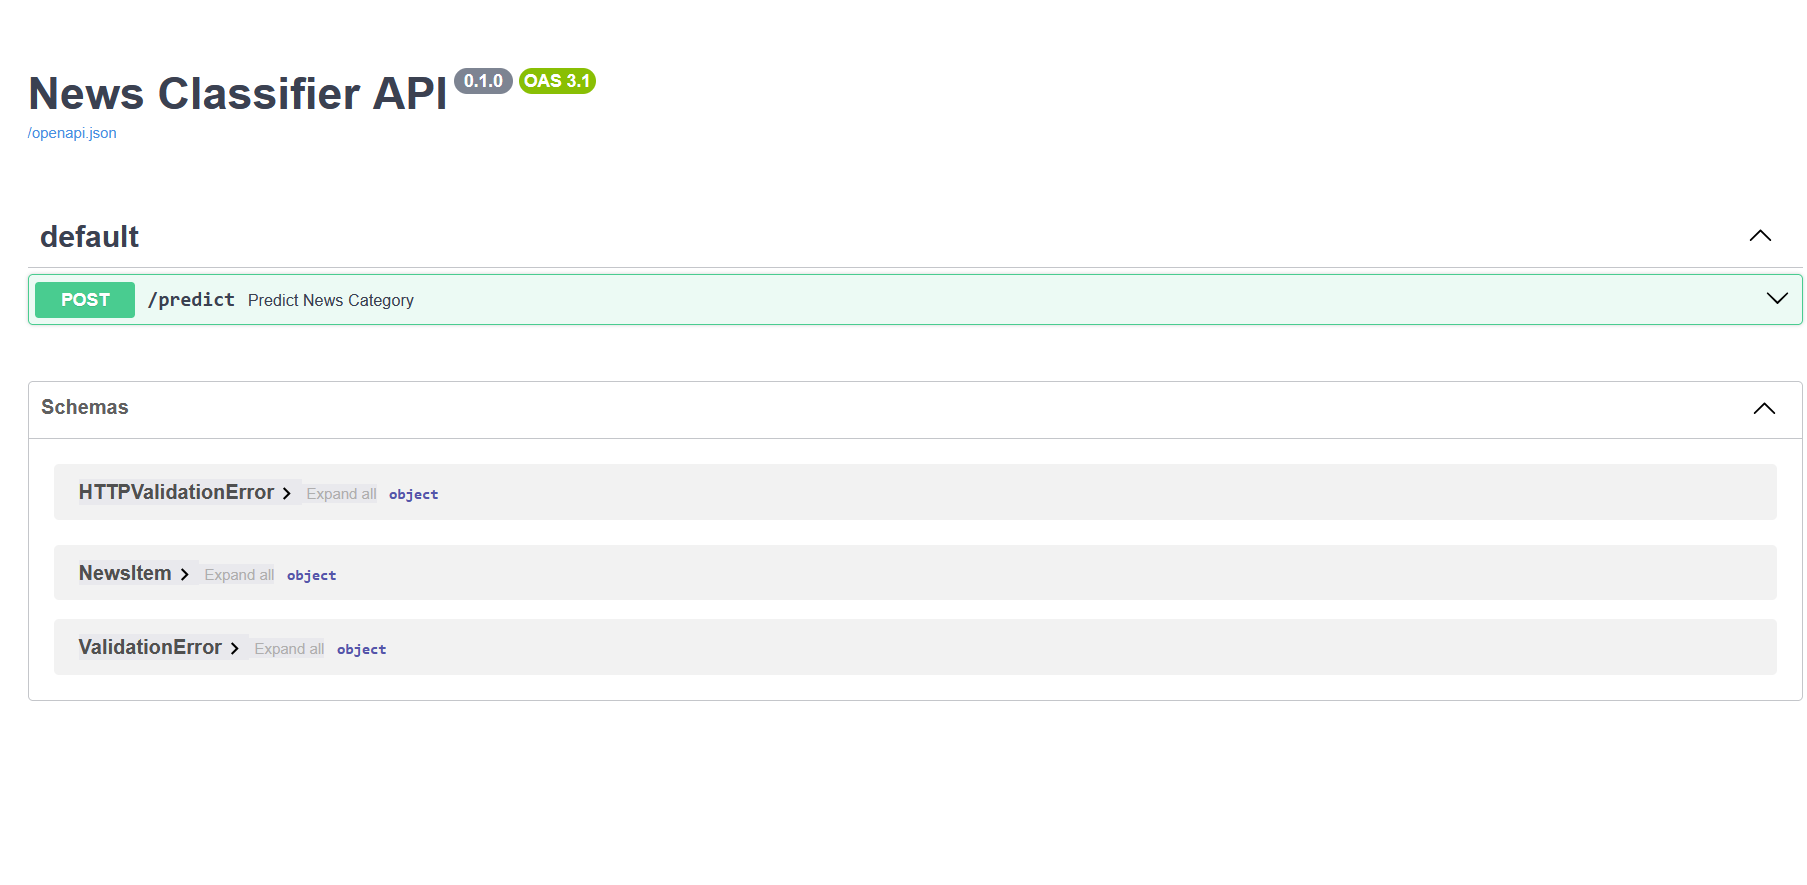

Открываем инструмент помощник Swagger, на данном скриншоте , нам отображается допустный один метод ,который был прописан на стороне сервера, для выявление к какой теме относиться наша статья

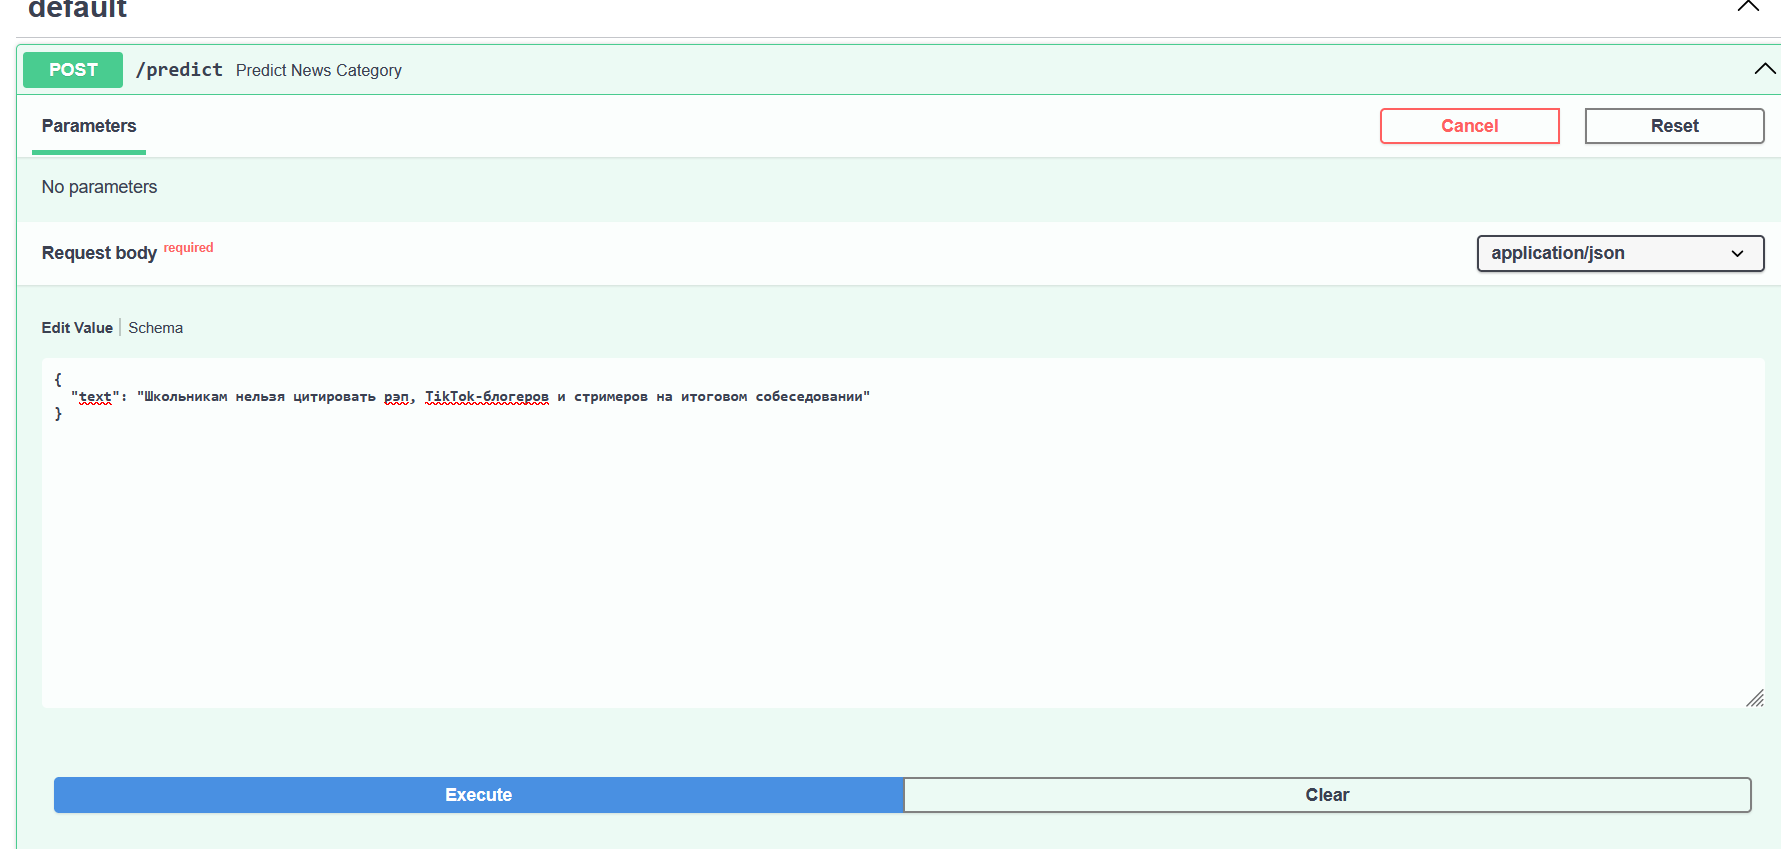

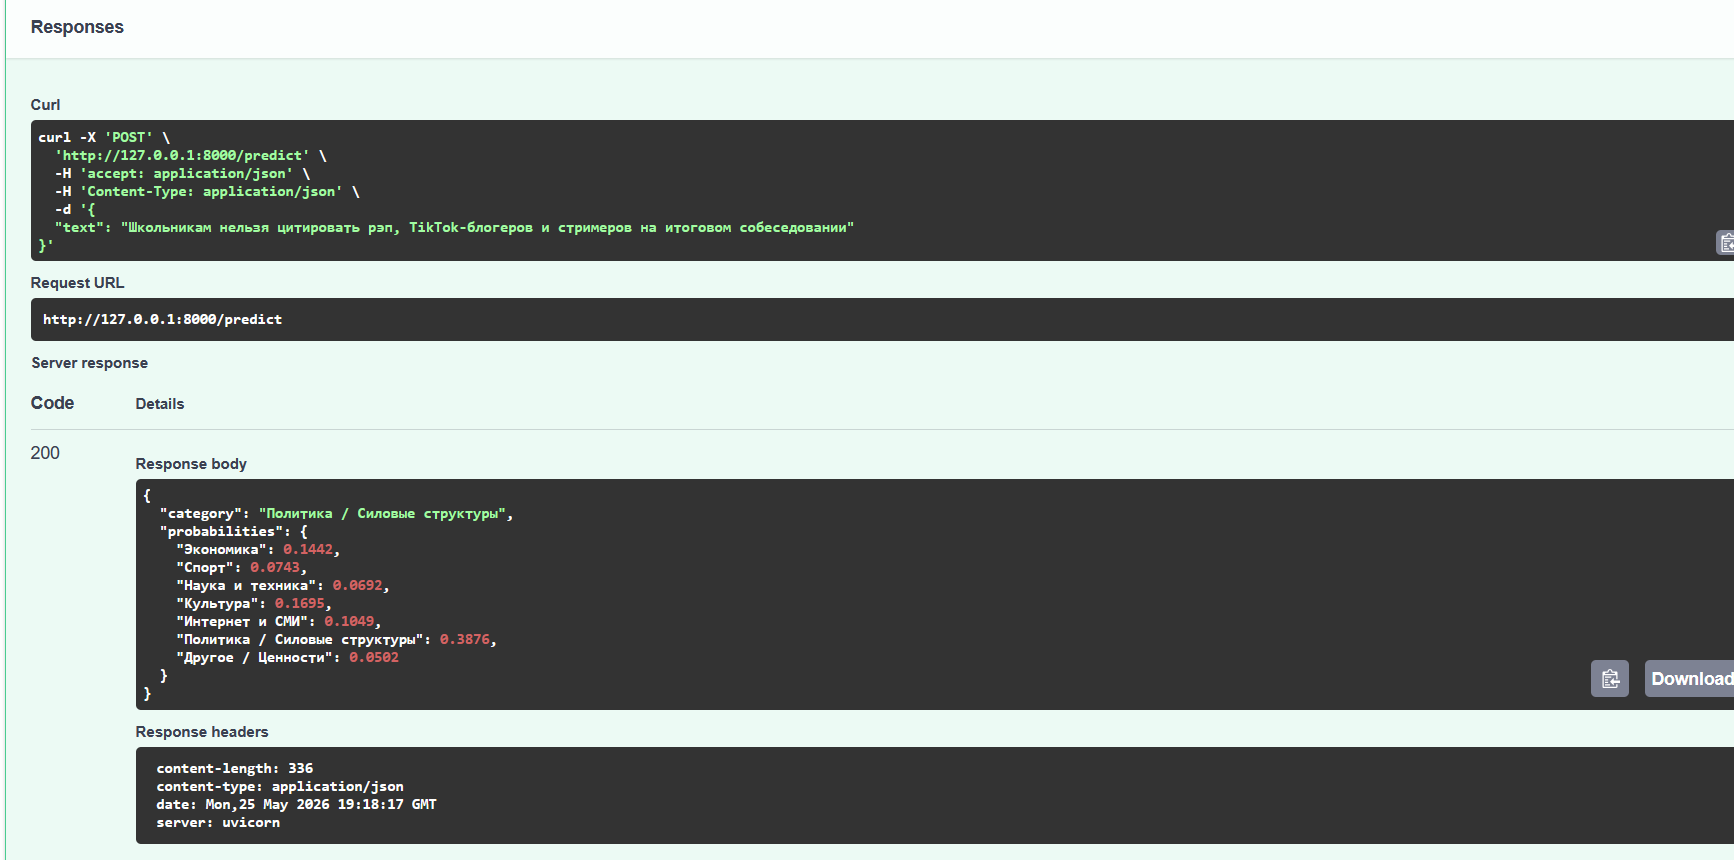

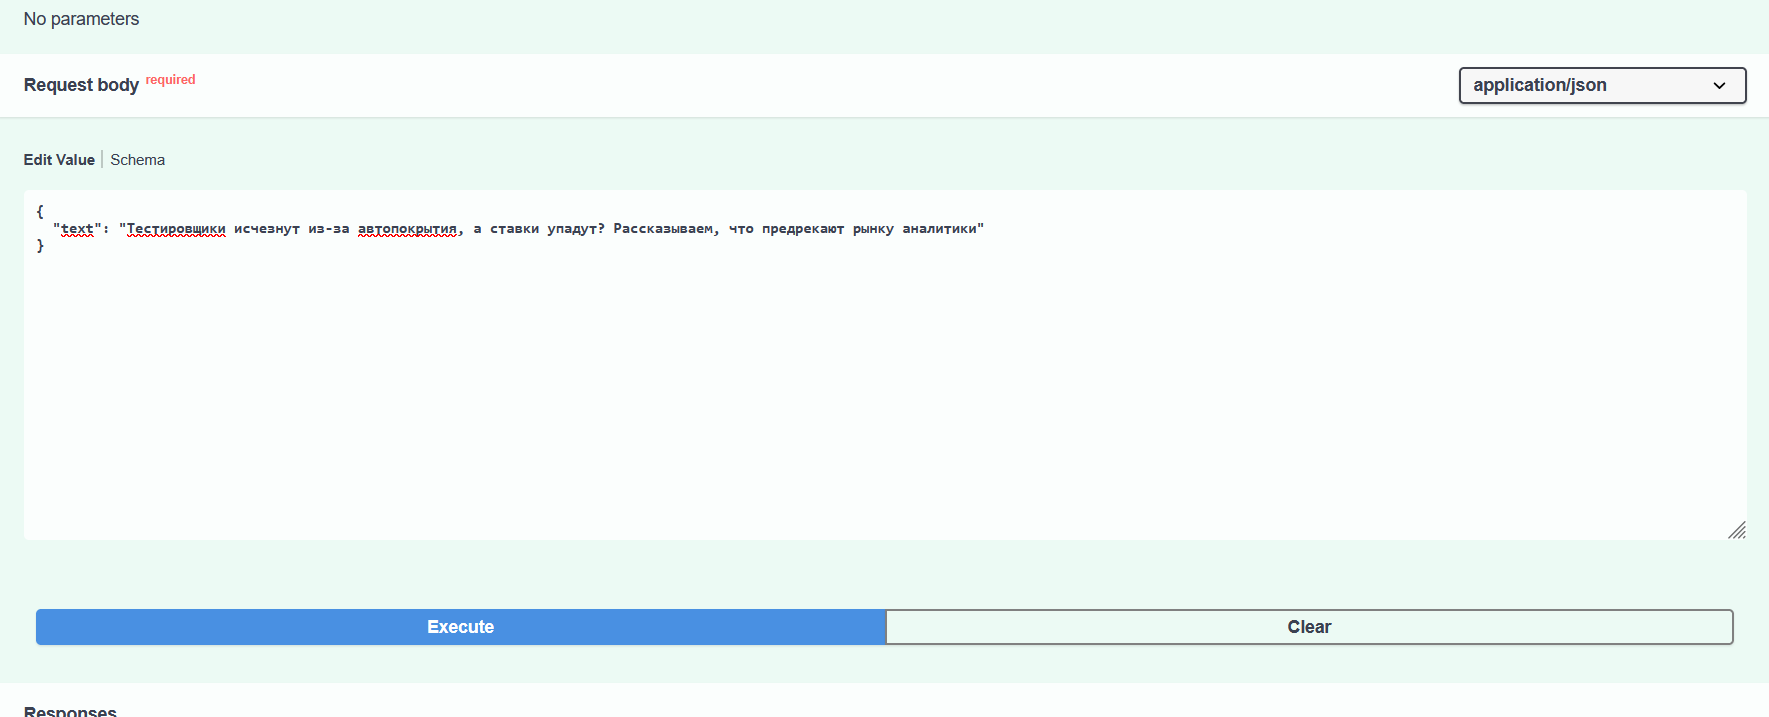

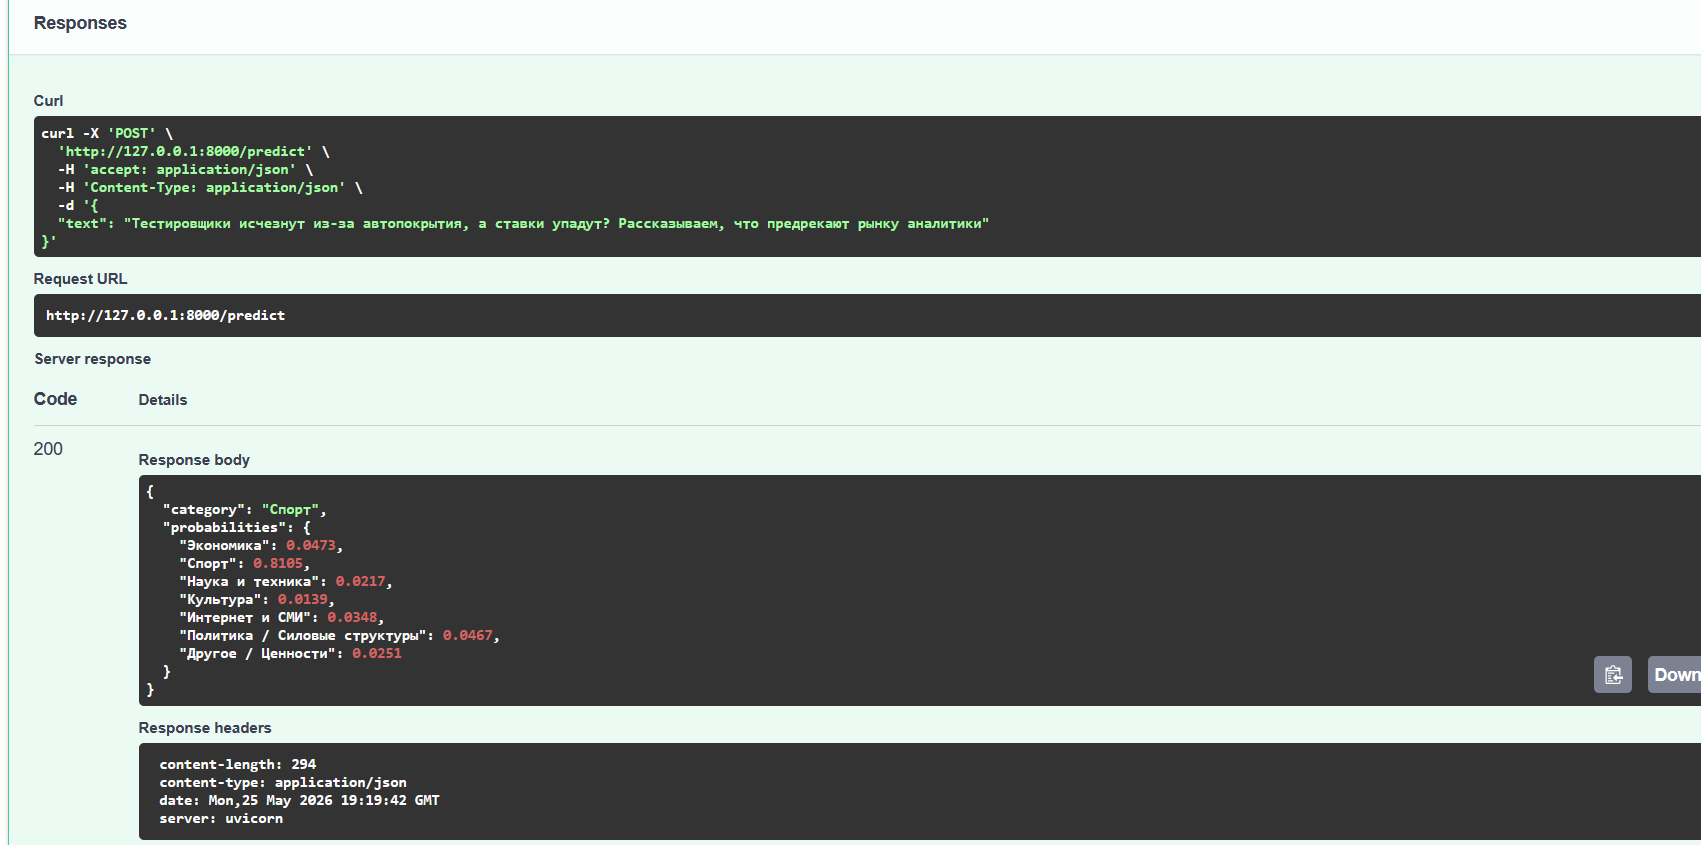

В инструменте swagger вставляем текст, какой нибудь статьи  и смотрим результат , также можно увидеть для каждой темы на сколько относиться эта статья 

# Модуль 8 Разработка приложения. 

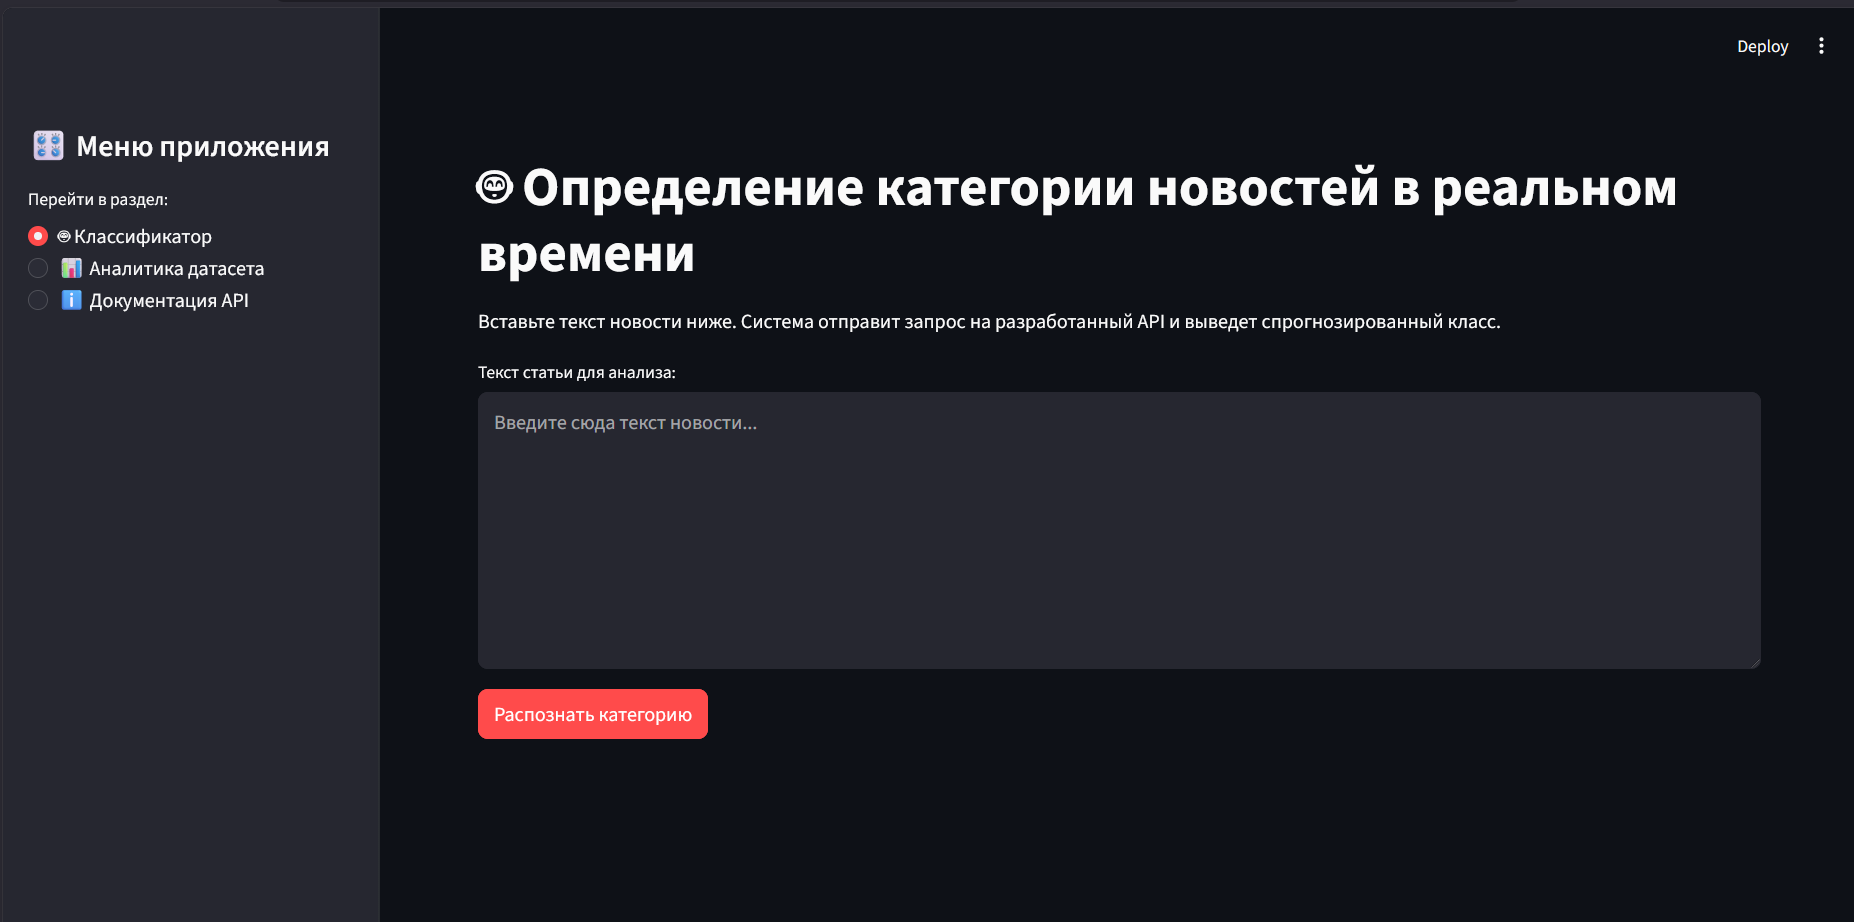

На данной странице нам выходит, что мы можем ввести текст для анализа названия новостей к какой группе относиться

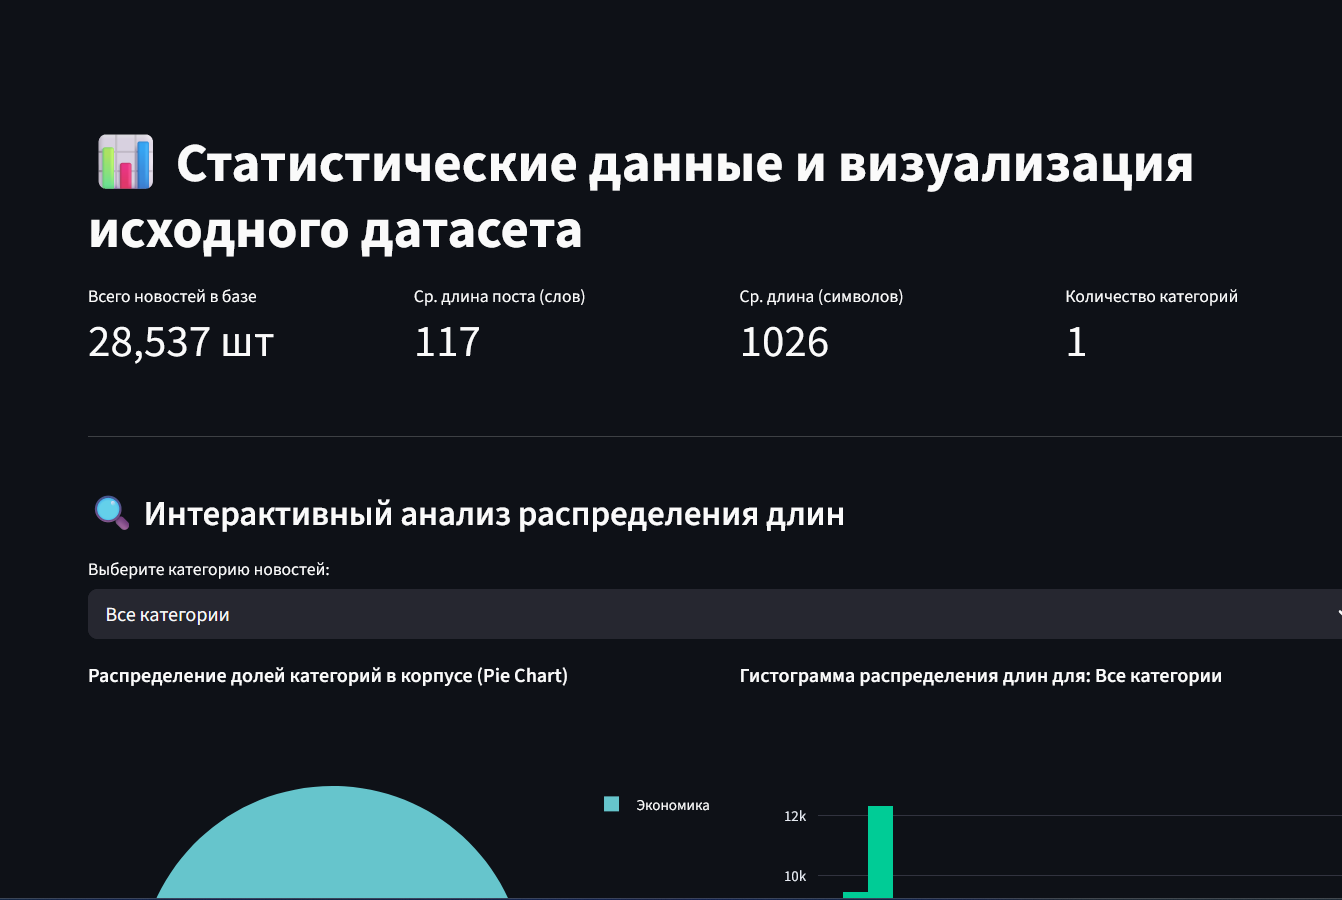

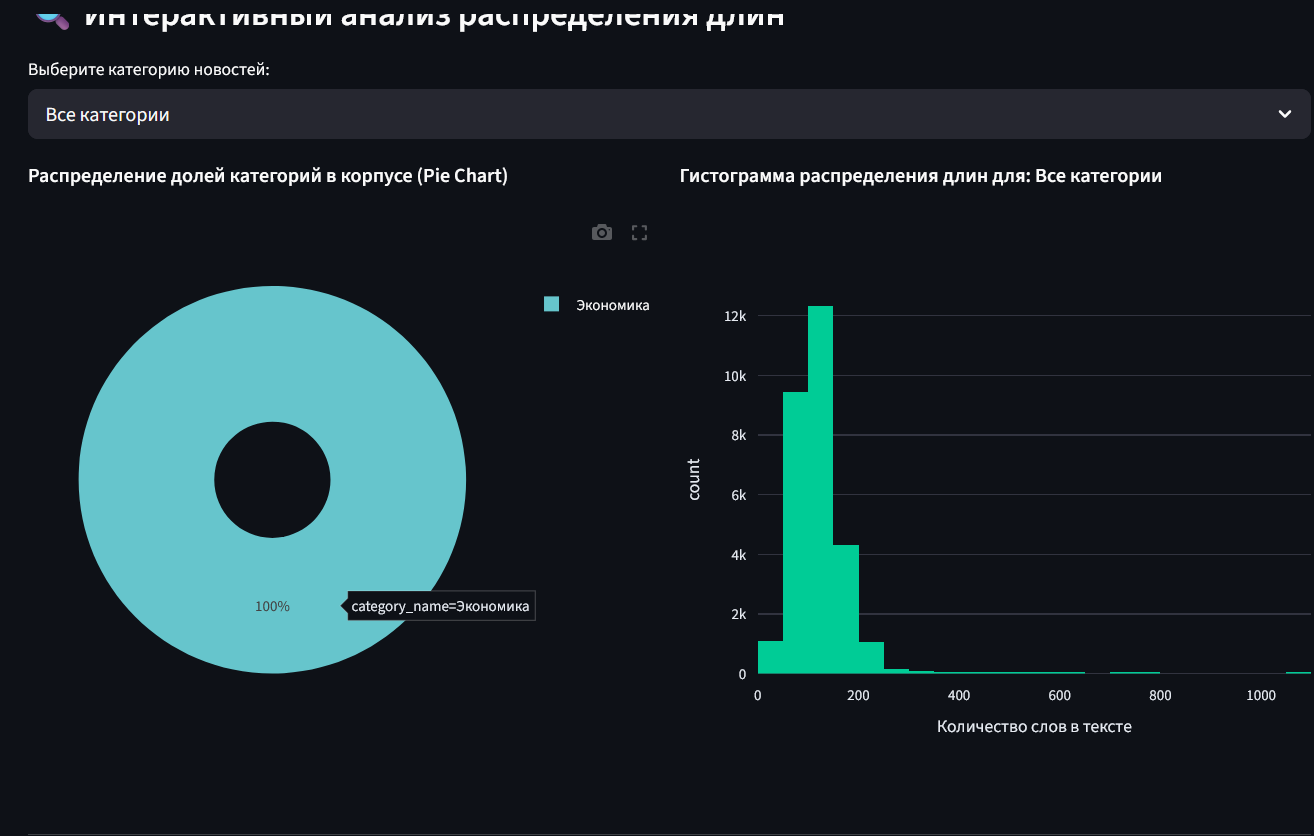

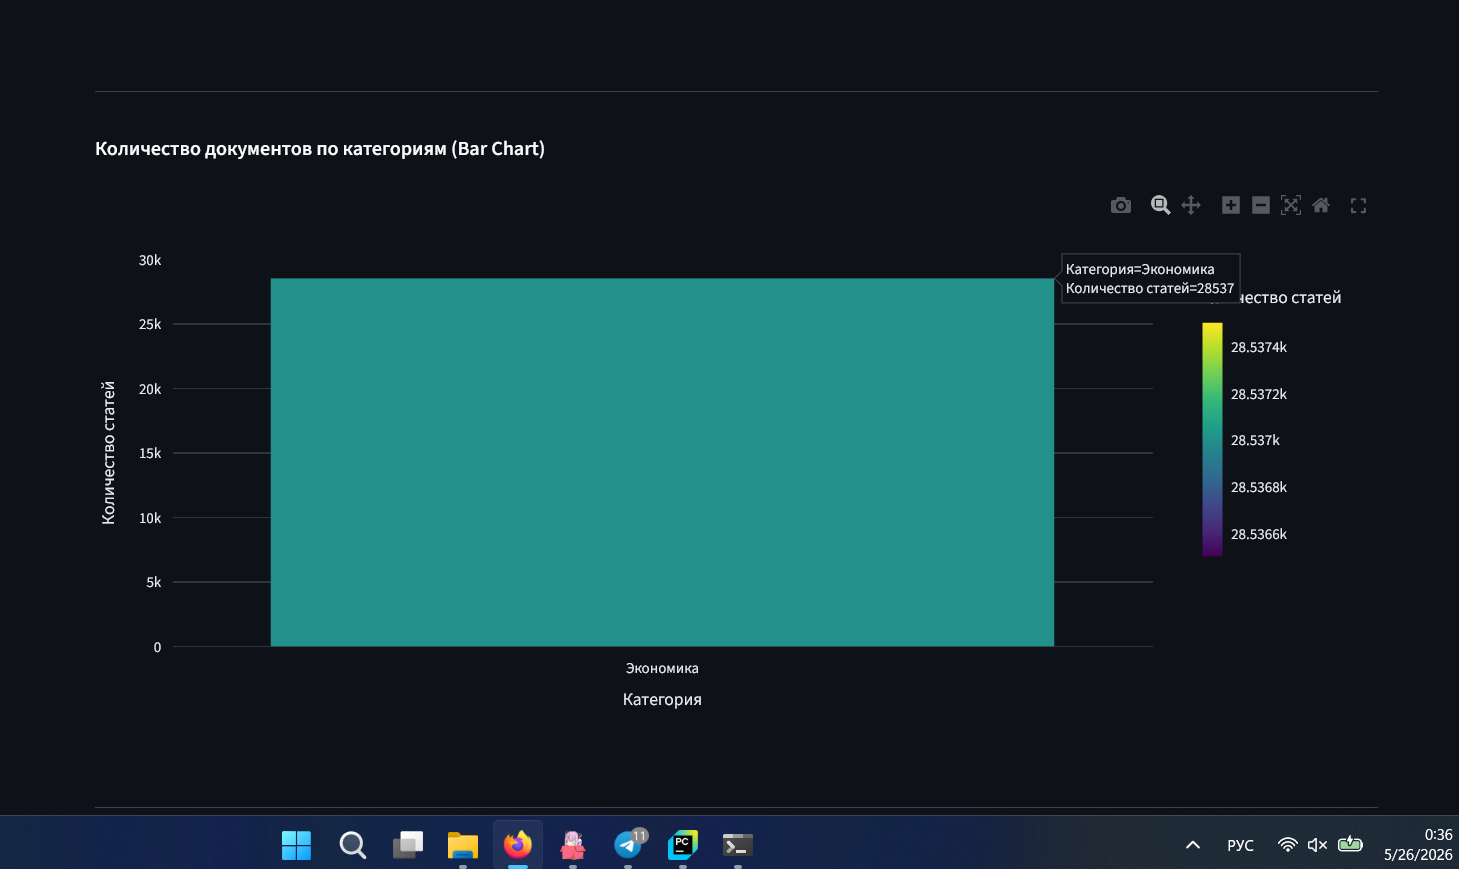

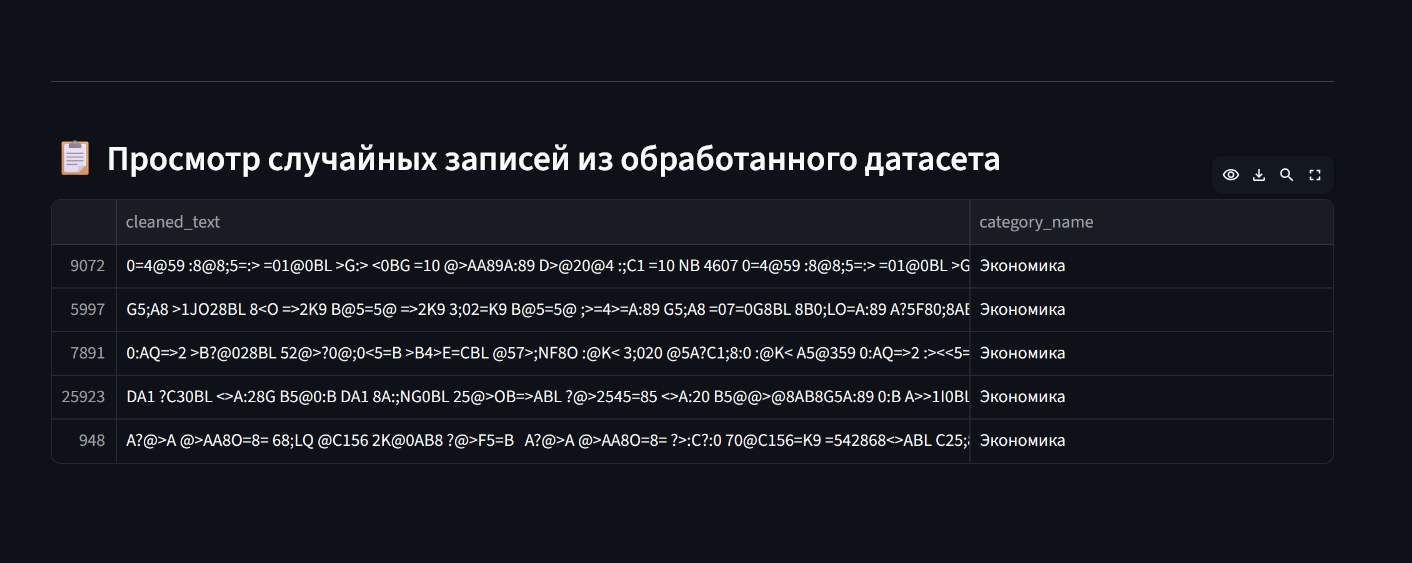

На данной вкладке, можем просмотреть аналитику по нашим данным, в самом вверху мы видим небольшую статистику по нашему датасету, далее видим графики и гистрограмму по категориям к сожалению на данном скрине представлена одна категория и в самом нам выводяться рандомные строки и какой она категории относиться 

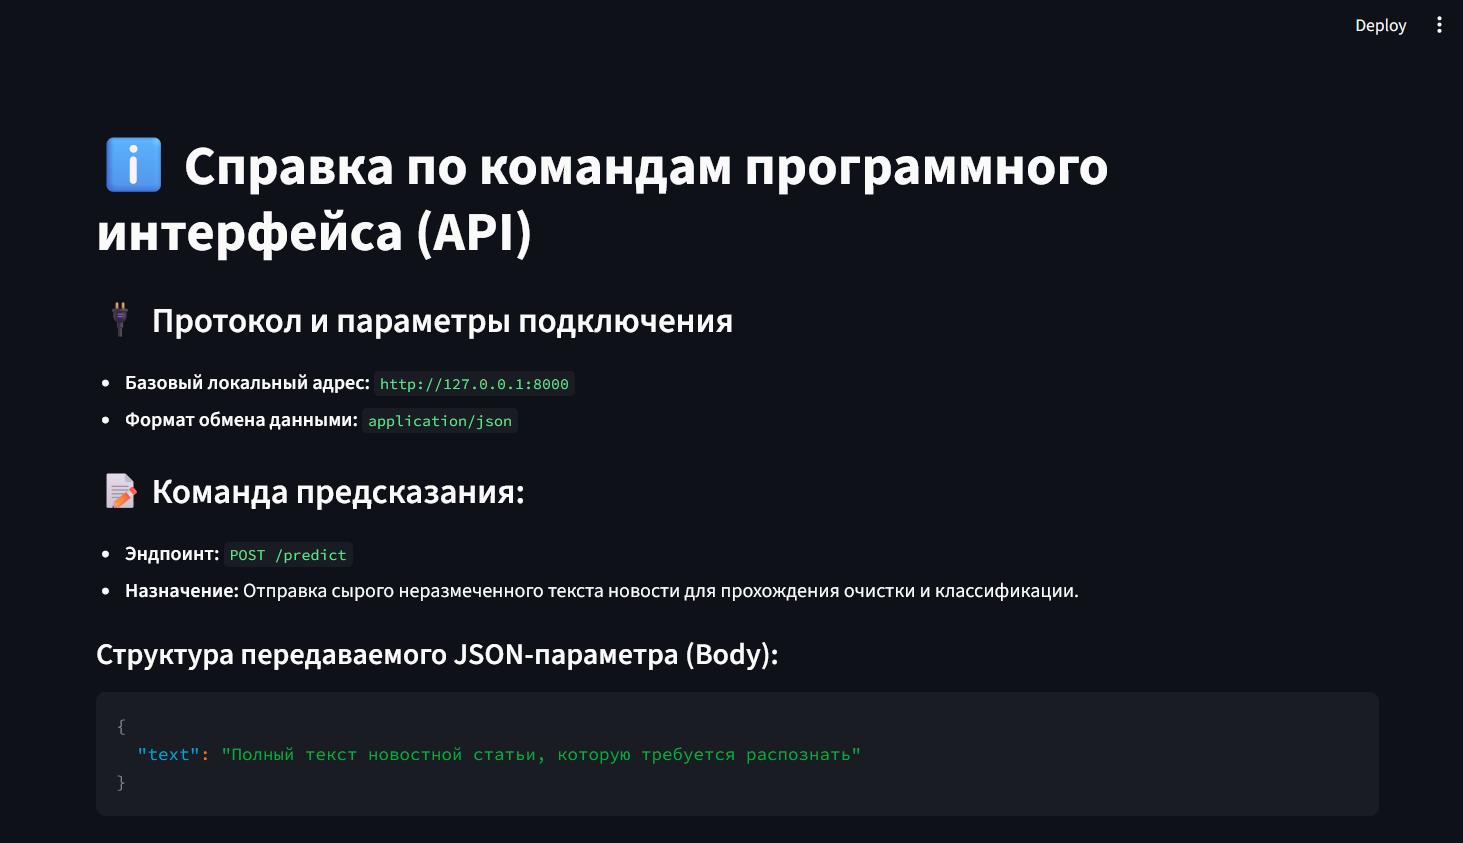

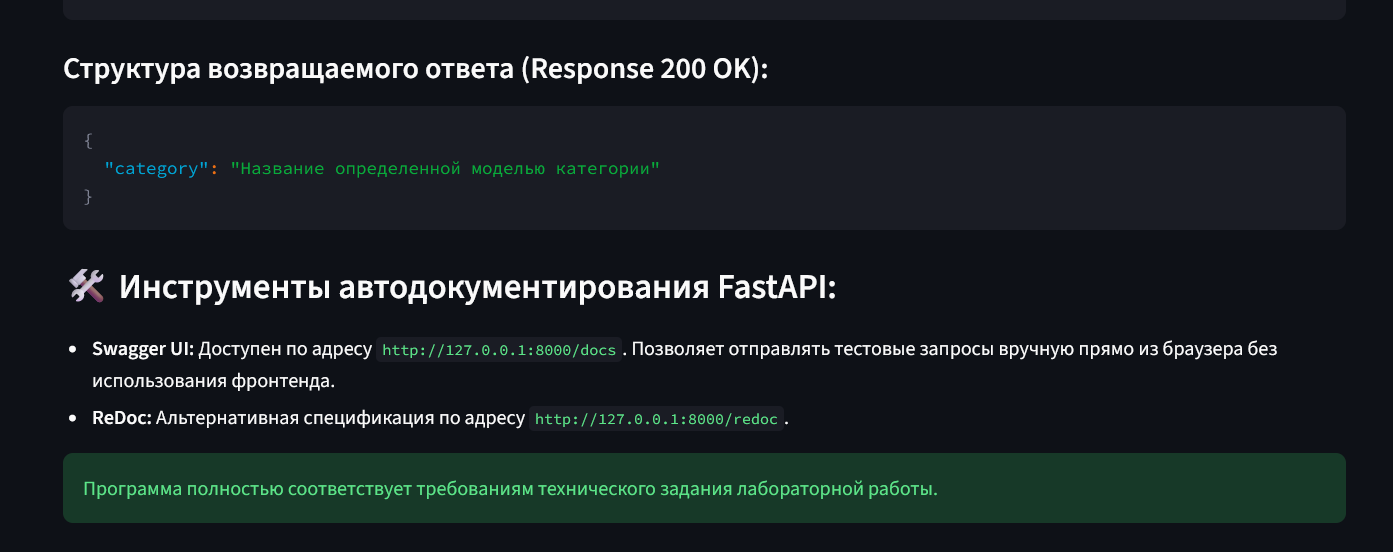

На данном  скрине представлено документация по использованию

# Итоговый вывод

В ходе выполнения работы была разработана система классификации новостей по категориям, реализующая полный цикл обработки данных: от загрузки и предобработки текстов до обучения модели, создания API и графического приложения.

На этапе анализа данных из исходного датасета были отобраны наиболее значимые признаки — заголовок, текст и категория. Проведена очистка текстов: удалены спецсимволы, стоп-слова, выполнена лемматизация и приведение к нижнему регистру.

Было обучено три модели классификации: логистическая регрессия, случайный лес и градиентный бустинг. Лучшую показала модель Random Forest с accuracy 95% и средневзвешенным F1-скором 0.95.

С помощью парсинга собрано 500+ новых новостей, проведено итеративное дообучение модели на примерах с высокой уверенностью классификатора (>0.8 и <0.2), что позволило улучшить её устойчивость на смежных темах.

Разработаны REST API на базе FastAPI и десктопное приложение с графическим интерфейсом, включающим вкладки для классификации, статистики и справки. Создана программная документация и руководство пользователя.

Итоговая система готова к практическому использованию и может быть адаптирована для других языков и тематик.